# 2026 CITS4012 Project
*Make sure you change the file name with your group id.*

# Readme
*If there is something to be noted for the marker, please mention here.*

*If you are planning to implement a program with Object Oriented Programming style, please put those the bottom of this ipynb file*

**Group 69 · Dataset: PIQA (Physical Interaction QA) · Main model: DACT (Difference-Aware Contrastive Transformer), trained from scratch.**

### How to run (clean Google Colab)
1. `Runtime → Change runtime type → GPU` (any GPU works: bf16 mixed precision is used on GPUs with native bf16 such as A100/L4, fp16 on others such as the free T4).
2. `Runtime → Run all`. The first data cell **downloads the four PIQA files automatically** from the unit's shared Google Drive folder (`Config.data_folder_url`). If that download fails, it falls back to the provided zip at **`MyDrive/Group69/PIQA.zip`** (mounting Google Drive), or change `Config.drive_zip`.
3. No other installation is needed: every package used (`torch`, `tokenizers`, `transformers`, `scikit-learn`, `scipy`, `pandas`, `matplotlib`) is pre-installed on Colab (only `gdown` is installed if missing); the first code cell prints the versions. The pretrained baselines (B3/B4) download `FacebookAI/roberta-base` and `Qwen/Qwen2.5-1.5B` from the Hugging Face Hub.
4. The last cell packs `outputs/` (logs, results, figures; no checkpoints) into `outputs.zip` and downloads it, and also copies it to Google Drive if Drive is mounted.

### Notes for the marker
* **Data usage.** No external data. The official PIQA training file is split 90/10 (stratified, seed 42) into *train* / *validation*. **All design decisions, hyper-parameter selection, early stopping and ablation comparisons use the validation split only.** The *test* split is touched only in the clearly marked *Final test evaluation* part of Section 3.
* **From scratch.** DACT and the BiLSTM baseline start from random initialisation; their BPE tokenizer is learned from the training split only. The optional masked-LM warm-up also uses only training-split text. Pretrained models appear only as baselines (B3, B4), and every baseline number is produced by the code in this notebook.
* **Logs.** Every run writes a JSON-lines log (`outputs/logs/*.jsonl`) with the full config and per-epoch metrics, and result summaries to `outputs/results/*.json|csv`. When Google Drive is mounted, the last cell copies `outputs/` (without checkpoints) to `MyDrive/Group69/outputs/`. The outputs saved in this notebook come from one clean top-to-bottom run of commit `5ef7cda` on a **free Colab Tesla T4** (fp16 mixed precision) on 2026-09-30, executed with the Colab CLI; the data were downloaded automatically from the unit's shared folder. The saved logs, result tables and figures of that run are submitted with this notebook in `outputs/`. (An earlier run of the pre-revision-2 code on an A100 is kept in the repository history; its numbers are not used here.)
* **Code organisation.** Model classes (`nn.Module`s) are in Section 2 (*Model Implementation*) because the notebook must run top-to-bottom; all remaining code is plain functions. The same code also exists as modules in our repository (`src/`); `python tools/sync_notebook.py` copies them into this notebook so the two cannot drift apart.
* **Revision 2.** (i) Over-long solutions are truncated *around the differing span* instead of keeping the prefix (`Config.diff_aware_truncation`, fixes the cobbler item in Section 3.3); (ii) new ablation *diff-bias prior 0* (`Config.tag_bias_init = 0`) tests whether the initial pooling bias matters; (iii) RoBERTa (B3) is fine-tuned with 3 seeds like the from-scratch models; (iv) an error-overlap analysis compares what DACT and the baselines get right; (v) attention controls separate learned attention from the built-in initial bias. All changes are recorded in `docs/DEVELOPMENT_LOG.md` (section 22).
* **Runtime.** About 1 h 40 min on a free T4 (about 6-14 s per DACT epoch, 170 s per RoBERTa epoch); about 60 min on an A100.

# 1.Dataset Processing
(You can add as many code blocks and text blocks as you need. However, YOU SHOULD NOT MODIFY the section title)

## 1.1 Environment check and configuration
All hyper-parameters live in one `Config` dataclass so that every experiment (including ablations) is a documented, logged variation of it.

In [ ]:
import os, sys, platform, importlib
SMOKE = os.environ.get("PIQA_SMOKE") == "1"   # local smoke test only; always False on Colab
for pkg in ["torch", "numpy", "sklearn", "scipy", "pandas", "matplotlib", "tokenizers", "transformers"]:
    print(f"{pkg:13s}", importlib.import_module(pkg).__version__)
import torch
print("python       ", platform.python_version())
print("GPU          ", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "none (switch the runtime to GPU)")

torch         2.11.0+cu128
numpy         2.1.3


sklearn       1.6.1
scipy         1.16.3
pandas        2.2.3
matplotlib    3.10.0
tokenizers    0.23.1


transformers  5.16.1
python        3.13.15
GPU           Tesla T4


In [ ]:
"""Global configuration, reproducibility and device helpers."""
import json
import os
import random
import time
from dataclasses import asdict, dataclass, replace

import numpy as np
import torch


@dataclass
class Config:
    # ---- paths ----
    # PIQA sub-folder of the unit's shared A2 dataset folder; on Colab the data is downloaded from here automatically
    data_folder_url: str = "https://drive.google.com/drive/folders/1lxEsHLbRsgOHh8rOAd75QHUZds7ybKtT"
    drive_zip: str = "/content/drive/MyDrive/Group69/PIQA.zip"  # Colab location of the provided data
    local_zip_glob: str = "*.zip"                               # fallback when running outside Colab
    data_dir: str = "data/piqa"
    out_dir: str = "outputs"

    # ---- data ----
    seed: int = 42              # seed for the train/validation split (kept fixed across runs)
    val_frac: float = 0.10
    vocab_size: int = 8000
    min_frequency: int = 2
    max_goal_len: int = 40      # BPE tokens
    max_sol_len: int = 96
    diff_aware_truncation: bool = True  # over-long solutions keep the window around the differing span, not the prefix

    # ---- model (DACT) ----
    d_model: int = 256
    n_heads: int = 4
    n_layers: int = 4
    d_ff: int = 1024
    dropout: float = 0.2
    attn_dropout: float = 0.1
    max_len: int = 160

    # ---- ablation switches ----
    use_diff_tags: bool = True        # difference-tag embedding
    use_cross_solution: bool = True   # sol1 <-> sol2 contrastive cross-attention
    pool_mode: str = "diff_attn"      # "diff_attn" | "attn" | "mean"
    tag_bias_init: float = 1.0        # initial pooling bias for difference-tagged tokens (0.0 = no built-in prior)
    use_lexical: bool = False         # "wide" head: learned weights of hashed solution unigrams/bigrams added to the score
    lex_buckets: int = 2 ** 18        # hash buckets of the lexical head
    objective: str = "pairwise"       # "pairwise" (softmax over the two options) | "pointwise" (independent BCE)
    mlm_epochs: int = 0               # in-domain masked-LM warm-up on the training split only

    # ---- optimisation ----
    batch_size: int = 128
    lr: float = 3e-4
    weight_decay: float = 0.05
    epochs: int = 20
    warmup_ratio: float = 0.06
    label_smoothing: float = 0.1
    patience: int = 6
    grad_clip: float = 1.0
    mlm_lr: float = 5e-4
    mlm_prob: float = 0.15
    amp: bool = True
    num_workers: int = 2

    def to_dict(self):
        return asdict(self)

    def but(self, **kw):
        """Return a copy with some fields overridden (used for ablations / seeds)."""
        return replace(self, **kw)


def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def get_device():
    if torch.cuda.is_available():
        # TF32 matmuls: large speed-up on Ampere+ GPUs (A100 / L4) with negligible accuracy impact
        torch.backends.cuda.matmul.allow_tf32 = True
        torch.backends.cudnn.allow_tf32 = True
        torch.backends.cudnn.benchmark = True
        return torch.device("cuda")
    if torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")


def amp_dtype(device):
    """bf16 autocast on GPUs with native bf16 (Ampere+), fp16 on older CUDA GPUs, disabled elsewhere.

    Only *native* support counts: a T4 reports bf16 as supported through emulation, which trains 3.5x slower than fp16.
    """
    if device.type != "cuda":
        return None
    return torch.bfloat16 if torch.cuda.is_bf16_supported(including_emulation=False) else torch.float16


class JsonlLogger:
    """Append-only JSON-lines logger so every training/evaluation run leaves a persistent log file."""

    def __init__(self, path):
        os.makedirs(os.path.dirname(path), exist_ok=True)
        self.path = path

    def log(self, **record):
        record = {"time": time.strftime("%Y-%m-%d %H:%M:%S"), **record}
        with open(self.path, "a") as f:
            f.write(json.dumps(record) + "\n")
        return record

In [ ]:
CFG = Config()
if SMOKE:
    CFG = CFG.but(epochs=1, d_model=64, d_ff=128, n_layers=2, batch_size=32, out_dir="outputs_nbsmoke")
DEVICE = torch.device("cpu") if SMOKE else get_device()
os.makedirs(CFG.out_dir, exist_ok=True)
print("device:", DEVICE, "| autocast dtype:", amp_dtype(DEVICE))

device: cuda | autocast dtype: torch.float16


## 1.2 Loading, splitting and tokenising PIQA
* Each item: a **goal** and two candidate **solutions**; the label says which solution is physically sensible.
* The provided `test` split (1,838 items) is only used at the very end; a stratified 10 % of the training file is held out as the **validation** split.
* **Tokenizer:** byte-pair encoding (8k merges vocabulary) *learned on the training split only*. PIQA has many rare, domain-specific words (tools, materials, recipes), so sub-words avoid a large `[UNK]` rate that a word-level vocabulary would have.
* **Difference tags:** the two solutions of an item are usually near-duplicates. We align their BPE sequences with `difflib.SequenceMatcher` and tag every solution token as *shared* or *different*. These tags are consumed by the model (Section 2).

In [ ]:
"""PIQA loading, train/validation split, BPE tokenizer, difference tags and batching."""
import difflib
import glob
import json
import os
import shutil
import subprocess
import sys
import zipfile

import numpy as np
import torch
from sklearn.model_selection import train_test_split
from tokenizers import Tokenizer, models, normalizers, pre_tokenizers, trainers
from torch.utils.data import DataLoader, Dataset


EXPECTED_FILES = ("train.jsonl", "train-labels.lst", "test.jsonl", "test-labels.lst")
SPECIALS = ["[PAD]", "[UNK]", "[CLS]", "[SEP]", "[MASK]"]
PAD, UNK, CLS, SEP, MASK = range(len(SPECIALS))

# difference-tag vocabulary
TAG_OTHER, TAG_SHARED, TAG_DIFF = 0, 1, 2   # goal/special tokens, token shared by both solutions, token unique to this solution


# ----------------------------------------------------------------------------------------------
# 1. Locating and extracting the data
# ----------------------------------------------------------------------------------------------
def _in_colab():
    try:
        import google.colab  # noqa: F401
        return True
    except ImportError:
        return False


def _find_zip(cfg: Config):
    if _in_colab():
        from google.colab import drive
        if not os.path.isdir("/content/drive/MyDrive"):
            drive.mount("/content/drive")
        if os.path.isfile(cfg.drive_zip):
            return cfg.drive_zip
        raise FileNotFoundError(f"PIQA zip not found at {cfg.drive_zip}. Update Config.drive_zip.")
    for path in [cfg.drive_zip, *sorted(glob.glob(cfg.local_zip_glob))]:
        if os.path.isfile(path) and zipfile.is_zipfile(path):
            with zipfile.ZipFile(path) as zf:
                names = {os.path.basename(n) for n in zf.namelist()}
            if set(EXPECTED_FILES) <= names:
                return path
    raise FileNotFoundError("No zip containing the PIQA files was found.")


def download_piqa(cfg: Config):
    """Downloads the four PIQA files from the unit's shared (public) Google Drive folder; True on success."""
    tmp = cfg.data_dir + "_download"
    try:
        try:
            import gdown
        except ImportError:
            subprocess.run([sys.executable, "-m", "pip", "install", "-q", "gdown"], check=True)
            import gdown
        gdown.download_folder(url=cfg.data_folder_url, output=tmp, quiet=True)
    except Exception as e:  # missing package, network or Drive quota problems: fall back to the zip
        print(f"Download from the shared folder failed ({e}); falling back to the data zip.")
        return False
    found = {os.path.basename(p): p for p in glob.glob(os.path.join(tmp, "**", "*"), recursive=True)}
    if not set(EXPECTED_FILES) <= set(found):
        return False
    os.makedirs(cfg.data_dir, exist_ok=True)
    for fname in EXPECTED_FILES:
        shutil.move(found[fname], os.path.join(cfg.data_dir, fname))
    shutil.rmtree(tmp, ignore_errors=True)
    print(f"Downloaded {EXPECTED_FILES} from the unit's shared folder -> {cfg.data_dir}")
    return True


def prepare_data(cfg: Config):
    """Puts the four PIQA files into cfg.data_dir: existing copy, else (on Colab) the shared folder, else the zip."""
    if all(os.path.isfile(os.path.join(cfg.data_dir, f)) for f in EXPECTED_FILES):
        return cfg.data_dir
    if _in_colab() and cfg.data_folder_url and download_piqa(cfg):
        return cfg.data_dir
    zpath = _find_zip(cfg)
    os.makedirs(cfg.data_dir, exist_ok=True)
    with zipfile.ZipFile(zpath) as zf:
        members = {os.path.basename(n): n for n in zf.namelist() if not n.endswith("/")}
        for fname in EXPECTED_FILES:
            with zf.open(members[fname]) as src, open(os.path.join(cfg.data_dir, fname), "wb") as dst:
                dst.write(src.read())
    print(f"Extracted {EXPECTED_FILES} from {zpath} -> {cfg.data_dir}")
    return cfg.data_dir


def load_split(data_dir, split):
    with open(os.path.join(data_dir, f"{split}.jsonl")) as f:
        rows = [json.loads(line) for line in f if line.strip()]
    with open(os.path.join(data_dir, f"{split}-labels.lst")) as f:
        labels = [int(line) for line in f if line.strip()]
    assert len(rows) == len(labels), f"{split}: {len(rows)} rows vs {len(labels)} labels"
    for r, y in zip(rows, labels):
        assert y in (0, 1)
        r["label"] = y
        for k in ("goal", "sol1", "sol2"):
            r[k] = " ".join(str(r[k]).split())  # collapse irregular whitespace
    return rows


def load_piqa(cfg: Config):
    """Returns train / validation (held out from the official training file) / test.

    The test split is returned separately and must only be used for the final evaluation.
    """
    data_dir = prepare_data(cfg)
    full_train = load_split(data_dir, "train")
    test = load_split(data_dir, "test")
    idx = np.arange(len(full_train))
    tr_idx, va_idx = train_test_split(idx, test_size=cfg.val_frac, random_state=cfg.seed,
                                      stratify=[r["label"] for r in full_train])
    train = [full_train[i] for i in tr_idx]
    val = [full_train[i] for i in va_idx]
    return train, val, test


# ----------------------------------------------------------------------------------------------
# 2. Tokenizer (BPE learned from the training split only)
# ----------------------------------------------------------------------------------------------
def train_tokenizer(train_rows, cfg: Config, path=None):
    tok = Tokenizer(models.BPE(unk_token="[UNK]"))
    tok.normalizer = normalizers.Sequence([normalizers.NFKC(), normalizers.Lowercase()])
    tok.pre_tokenizer = pre_tokenizers.Sequence([pre_tokenizers.Whitespace(), pre_tokenizers.Digits(individual_digits=True)])
    trainer = trainers.BpeTrainer(vocab_size=cfg.vocab_size, min_frequency=cfg.min_frequency,
                                  special_tokens=SPECIALS, continuing_subword_prefix="##")
    corpus = (text for r in train_rows for text in (r["goal"], r["sol1"], r["sol2"]))
    tok.train_from_iterator(corpus, trainer=trainer, length=3 * len(train_rows))
    if path:
        os.makedirs(os.path.dirname(path), exist_ok=True)
        tok.save(path)
    return tok


def diff_tags(a, b):
    """Token-level alignment of two solutions: TAG_SHARED where aligned-equal, TAG_DIFF otherwise."""
    ta, tb = [TAG_DIFF] * len(a), [TAG_DIFF] * len(b)
    sm = difflib.SequenceMatcher(None, a, b, autojunk=False)
    for tag, i1, i2, j1, j2 in sm.get_opcodes():
        if tag == "equal":
            ta[i1:i2] = [TAG_SHARED] * (i2 - i1)
            tb[j1:j2] = [TAG_SHARED] * (j2 - j1)
    return ta, tb


def truncate_around_diff(ids, tags, max_len):
    """Keeps a window of max_len tokens that covers as much of the differing span as possible.

    Plain prefix truncation can cut off the only differing words of two near-identical long solutions,
    making the two inputs identical (e.g. test item 1433).
    """
    if len(ids) <= max_len:
        return ids, tags
    diff_pos = [i for i, t in enumerate(tags) if t == TAG_DIFF]
    if not diff_pos:
        return ids[:max_len], tags[:max_len]
    first, last = diff_pos[0], diff_pos[-1]
    start = first - max(0, max_len - (last - first + 1)) // 2   # centre the differing span in the window
    start = min(max(0, start), len(ids) - max_len)
    return ids[start:start + max_len], tags[start:start + max_len]


def encode_example(row, tok, cfg: Config):
    """Encodes one PIQA item into two sequences [CLS] goal [SEP] sol_i [SEP] plus side information."""
    g = tok.encode(row["goal"]).ids[: cfg.max_goal_len]
    s1, s2 = tok.encode(row["sol1"]).ids, tok.encode(row["sol2"]).ids
    if cfg.diff_aware_truncation:
        t1, t2 = diff_tags(s1, s2)   # align the full solutions, then cut both around their differences
        s1, t1 = truncate_around_diff(s1, t1, cfg.max_sol_len)
        s2, t2 = truncate_around_diff(s2, t2, cfg.max_sol_len)
    else:
        s1, s2 = s1[: cfg.max_sol_len], s2[: cfg.max_sol_len]
        t1, t2 = diff_tags(s1, s2)
    out = []
    for s, t in ((s1, t1), (s2, t2)):
        ids = [CLS] + g + [SEP] + s + [SEP]
        seg = [0] * (len(g) + 2) + [1] * (len(s) + 1)
        tags = [TAG_OTHER] * (len(g) + 2) + t + [TAG_OTHER]
        sol = [0] * (len(g) + 2) + [1] * len(s) + [0]   # positions that belong to the solution text
        out.append((ids, seg, tags, sol))
    return out


class PIQADataset(Dataset):
    """Pre-tokenises everything once so the GPU is not starved by Python-side work."""

    def __init__(self, rows, tok, cfg: Config):
        self.rows = rows
        self.items = [encode_example(r, tok, cfg) for r in rows]
        self.labels = [r["label"] for r in rows]

    def __len__(self):
        return len(self.items)

    def __getitem__(self, i):
        return self.items[i], self.labels[i], i


def collate(batch):
    """Pads a batch into tensors of shape [B, 2, L]."""
    B = len(batch)
    L = max(len(seq[0]) for item, _, _ in batch for seq in item)
    ids = torch.full((B, 2, L), PAD, dtype=torch.long)
    seg = torch.zeros((B, 2, L), dtype=torch.long)
    tags = torch.zeros((B, 2, L), dtype=torch.long)
    sol = torch.zeros((B, 2, L), dtype=torch.bool)
    for b, (item, _, _) in enumerate(batch):
        for k, (i_, s_, t_, m_) in enumerate(item):
            n = len(i_)
            ids[b, k, :n] = torch.tensor(i_)
            seg[b, k, :n] = torch.tensor(s_)
            tags[b, k, :n] = torch.tensor(t_)
            sol[b, k, :n] = torch.tensor(m_, dtype=torch.bool)
    return {
        "input_ids": ids, "segment": seg, "tags": tags, "sol_mask": sol,
        "attn_mask": ids != PAD,
        "labels": torch.tensor([y for _, y, _ in batch], dtype=torch.long),
        "index": torch.tensor([i for _, _, i in batch], dtype=torch.long),
    }


def make_loader(ds, cfg: Config, shuffle, device):
    return DataLoader(ds, batch_size=cfg.batch_size, shuffle=shuffle, collate_fn=collate,
                      num_workers=cfg.num_workers if device.type == "cuda" else 0,
                      pin_memory=device.type == "cuda", persistent_workers=False)


def prepare_everything(cfg: Config):
    """Loads the splits, learns the BPE tokenizer on the training split and pre-tokenises every split."""
    train, val, test = load_piqa(cfg)
    tok = train_tokenizer(train, cfg, path=os.path.join(cfg.out_dir, "tokenizer.json"))
    return {"train": train, "val": val, "test": test, "tok": tok, "vocab_size": tok.get_vocab_size(),
            "train_ds": PIQADataset(train, tok, cfg), "val_ds": PIQADataset(val, tok, cfg),
            "test_ds": PIQADataset(test, tok, cfg)}


def token_strings(tok, ids):
    return [tok.id_to_token(int(i)) for i in ids]

In [ ]:
DATA = prepare_everything(CFG)
if SMOKE:
    for split in ("train", "val", "test"):
        ds = DATA[f"{split}_ds"]
        ds.items, ds.labels, ds.rows = ds.items[:256], ds.labels[:256], ds.rows[:256]
        DATA[split] = DATA[split][:256]
print({s: len(DATA[s]) for s in ("train", "val", "test")}, "| vocab size:", DATA["vocab_size"])
print("example:", DATA["train"][0])
enc = DATA["train_ds"].items[0]
print([(t, tag) for t, tag in zip(token_strings(DATA["tok"], enc[0][0]), enc[0][2])])

{'train': 14501, 'val': 1612, 'test': 1838} | vocab size: 8000
example: {'goal': 'how do you scissor something?', 'sol1': 'cut it open.', 'sol2': 'close it.', 'label': 0}
[('[CLS]', 0), ('how', 0), ('do', 0), ('you', 0), ('scissor', 0), ('something', 0), ('?', 0), ('[SEP]', 0), ('cut', 2), ('it', 1), ('open', 2), ('.', 1), ('[SEP]', 0)]


,split,items,label=1 share,goal BPE len (mean),solution BPE len (mean),solution BPE len (p99),differing-token share (median)
0,train,14501,0.500,8.299,21.670,96.0,0.150
1,val,1612,0.500,8.525,22.043,96.0,0.143
2,test,1838,0.505,8.465,21.821,96.0,0.154


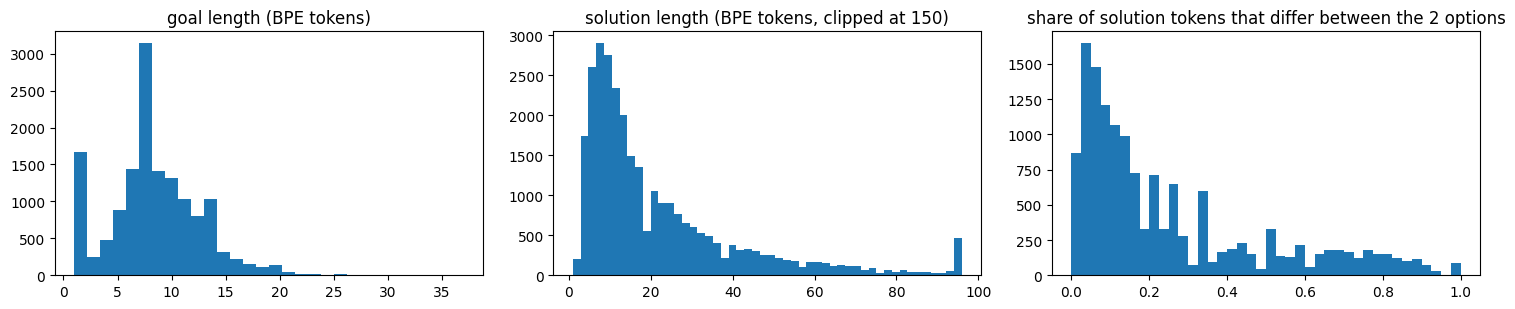

In [ ]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt

def split_stats(ds):
    goal_len = [sum(1 for s in it[0][1] if s == 0) - 2 for it in ds.items]
    sol_len = [sum(it[k][3]) for it in ds.items for k in (0, 1)]
    diff_share = [np.mean([t == TAG_DIFF for k in (0, 1) for t, m in zip(it[k][2], it[k][3]) if m] or [0]) for it in ds.items]
    return goal_len, sol_len, diff_share

rows = []
for split in ("train", "val", "test"):
    g, s, d = split_stats(DATA[f"{split}_ds"])
    rows.append({"split": split, "items": len(DATA[f"{split}_ds"]),
                 "label=1 share": np.mean(DATA[f"{split}_ds"].labels),
                 "goal BPE len (mean)": np.mean(g), "solution BPE len (mean)": np.mean(s),
                 "solution BPE len (p99)": np.percentile(s, 99),
                 "differing-token share (median)": np.median(d)})
display(pd.DataFrame(rows).round(3))

g, s, d = split_stats(DATA["train_ds"])
fig, ax = plt.subplots(1, 3, figsize=(15, 3.2))
ax[0].hist(g, bins=30); ax[0].set_title("goal length (BPE tokens)")
ax[1].hist(np.clip(s, 0, 150), bins=50); ax[1].set_title("solution length (BPE tokens, clipped at 150)")
ax[2].hist(d, bins=40); ax[2].set_title("share of solution tokens that differ between the 2 options")
plt.tight_layout(); plt.show()

**What the statistics imply for the design.**
* Labels are balanced, so **accuracy** is an unbiased metric and chance level is 50 %.
* In the median item only a small fraction of solution tokens differ between the two options (right histogram): the answer depends on a few words (*paper strips* vs *jeans material*, *weld* vs *nail*) placed inside otherwise identical text. A model that encodes each option independently must discover this small signal on its own from only 14.5k training items. DACT therefore (i) marks the differing tokens explicitly, (ii) compares the two options with cross-attention and (iii) biases its pooling towards the differing tokens.
* Solutions are short (p99 of about 100 BPE tokens), so we truncate solutions to 96 and goals to 40 tokens.

# 2. Model Implementation
(You can add as many code blocks and text blocks as you need. However, YOU SHOULD NOT MODIFY the section title)

## 2.1 DACT: Difference-Aware Contrastive Transformer

```
 goal + sol1 ─┐                                     ┌─ diff-guided attention pooling ─┐
              ├─ shared Transformer encoder ─ h1 ─┐ │                                 ├─ scorer → s1 ┐
 tags(sol1)  ─┘   (token+pos+segment+DIFF-TAG)    ├─┤ contrastive cross-solution attn │              ├─ softmax → P(option)
 goal + sol2 ─┐                                   │ │   h_i attends to h_j, fuse      │              │
              ├─ shared Transformer encoder ─ h2 ─┘ │   [h; c; h−c; h⊙c]              ├─ scorer → s2 ┘
 tags(sol2)  ─┘                                     └─────────────────────────────────┘
```

| Component | Standard choice | Our PIQA-specific change | Why |
|---|---|---|---|
| Input embedding | token + position (+ segment) | **+ difference-tag embedding** (goal/special, shared, different) | Tells the encoder from layer 1 where the two options disagree, so it does not have to learn this from 14.5k items |
| Option interaction | options scored independently | **Contrastive cross-solution attention**: each token of option *i* attends to the tokens of option *j* (plus a `[CLS]` sink for "no counterpart"), fused ESIM-style with `[h; c; h−c; h⊙c]` | Physical plausibility is relative ("jar" vs "plate"); the comparison features encode what replaced what |
| Summary vector | `[CLS]` or mean pooling | **Difference-guided additive attention pooling** with a learned bias per tag | Puts the decision on the few decisive tokens while the pooling weights remain interpretable |
| Objective | independent binary classification | **Pairwise softmax** over the two option scores (label smoothing 0.1) | Matches the forced-choice task |
| Encoder | post-LN Transformer | Pre-LN, shared across options, GELU, dropout 0.2 | Stable training from scratch; weight sharing makes the model **permutation-equivariant** (swapping options swaps scores, verified below), so it cannot learn a position bias |
| (optional) warm-up | none | Masked-LM warm-up on training-split text only | Compensates for the small labelled set without external data; kept only if it helps on validation |

Every component can be switched off in `Config`, which is how the ablations in Section 3 are run.

In [ ]:
"""DACT: Difference-Aware Contrastive Transformer for PIQA (trained from scratch).

Pipeline for one PIQA item (goal g, solutions s1, s2):
  1. each option is encoded as [CLS] g [SEP] s_i [SEP] by a shared Transformer encoder whose input embedding
     = token + position + segment + DIFFERENCE TAG (shared-with-other-option / unique-to-this-option);
  2. CONTRASTIVE CROSS-SOLUTION ATTENTION lets every token of s_i attend to the tokens of s_j, and fuses
     [h; c; h-c; h*c] so the representation explicitly encodes how this option differs from its rival;
  3. DIFFERENCE-GUIDED ATTENTION POOLING summarises each option with a learned bias towards differing tokens;
  4. a shared scorer produces one logit per option; the two logits compete in a softmax.
The same weights process both options, so the model is permutation-equivariant in the option order.
"""
import math

import torch
import torch.nn as nn
import torch.nn.functional as F


class MultiHeadAttention(nn.Module):
    """Multi-head scaled dot-product attention.

    Uses the fused SDPA kernel for speed during training, and an explicit implementation when the attention
    weights are requested for visualisation.
    """

    def __init__(self, d_model, n_heads, attn_dropout):
        super().__init__()
        assert d_model % n_heads == 0
        self.h, self.dh = n_heads, d_model // n_heads
        self.q = nn.Linear(d_model, d_model)
        self.k = nn.Linear(d_model, d_model)
        self.v = nn.Linear(d_model, d_model)
        self.o = nn.Linear(d_model, d_model)
        self.p = attn_dropout

    def forward(self, x, kv, key_mask, return_attn=False):
        B, Lq, D = x.shape
        Lk = kv.size(1)
        q = self.q(x).view(B, Lq, self.h, self.dh).transpose(1, 2)
        k = self.k(kv).view(B, Lk, self.h, self.dh).transpose(1, 2)
        v = self.v(kv).view(B, Lk, self.h, self.dh).transpose(1, 2)
        mask = key_mask[:, None, None, :]          # True = may attend
        p = self.p if self.training else 0.0
        attn = None
        if return_attn:
            scores = (q @ k.transpose(-2, -1)) / math.sqrt(self.dh)
            scores = scores.masked_fill(~mask, float("-inf"))
            attn = torch.nan_to_num(scores.float().softmax(-1)).to(q.dtype)
            out = F.dropout(attn, p, self.training) @ v
        else:
            out = F.scaled_dot_product_attention(q, k, v, attn_mask=mask, dropout_p=p)
        return self.o(out.transpose(1, 2).reshape(B, Lq, D)), attn


class EncoderLayer(nn.Module):
    """Pre-LayerNorm Transformer encoder block (more stable than post-LN when training from scratch)."""

    def __init__(self, cfg: Config):
        super().__init__()
        self.ln1 = nn.LayerNorm(cfg.d_model)
        self.attn = MultiHeadAttention(cfg.d_model, cfg.n_heads, cfg.attn_dropout)
        self.ln2 = nn.LayerNorm(cfg.d_model)
        self.ff = nn.Sequential(nn.Linear(cfg.d_model, cfg.d_ff), nn.GELU(), nn.Dropout(cfg.dropout),
                                nn.Linear(cfg.d_ff, cfg.d_model))
        self.drop = nn.Dropout(cfg.dropout)

    def forward(self, x, key_mask, return_attn=False):
        a, w = self.attn(self.ln1(x), self.ln1(x), key_mask, return_attn)
        x = x + self.drop(a)
        x = x + self.drop(self.ff(self.ln2(x)))
        return x, w


class ContrastiveCrossSolution(nn.Module):
    """Each option's tokens attend to the rival option's solution tokens; ESIM-style comparison fusion."""

    def __init__(self, cfg: Config):
        super().__init__()
        d = cfg.d_model
        self.ln = nn.LayerNorm(d)
        self.attn = MultiHeadAttention(d, cfg.n_heads, cfg.attn_dropout)
        self.fuse = nn.Sequential(nn.Linear(4 * d, d), nn.GELU(), nn.Dropout(cfg.dropout), nn.Linear(d, d))
        self.out_ln = nn.LayerNorm(d)
        self.drop = nn.Dropout(cfg.dropout)

    def forward(self, h_self, h_other, other_key_mask, return_attn=False):
        q, kv = self.ln(h_self), self.ln(h_other)
        c, w = self.attn(q, kv, other_key_mask, return_attn)
        m = self.fuse(torch.cat([q, c, q - c, q * c], dim=-1))
        return self.out_ln(h_self + self.drop(m)), w


class AttentionPooling(nn.Module):
    """Additive attention pooling over solution tokens.

    mode="diff_attn": score_t = v^T tanh(W h_t) + b[tag_t]  (learned bias per difference tag)
    mode="attn":      same without the tag bias
    mode="mean":      uniform average (ablation)
    """

    def __init__(self, d_model, mode, diff_bias_init=1.0):
        super().__init__()
        self.mode = mode
        self.proj = nn.Linear(d_model, d_model)
        self.v = nn.Linear(d_model, 1, bias=False)
        self.tag_bias = nn.Parameter(torch.tensor([0.0, 0.0, diff_bias_init]))  # other, shared, diff

    def forward(self, h, mask, tags):
        mask = mask.clone()
        mask[~mask.any(-1), 0] = True  # empty solution -> fall back to [CLS]
        if self.mode == "mean":
            w = mask.float() / mask.float().sum(-1, keepdim=True)
        else:
            s = self.v(torch.tanh(self.proj(h))).squeeze(-1).float()
            if self.mode == "diff_attn":
                s = s + self.tag_bias[tags]
            w = s.masked_fill(~mask, float("-inf")).softmax(-1)
        pooled = torch.einsum("nl,nld->nd", w.to(h.dtype), h)
        return pooled, w


class DACT(nn.Module):
    def __init__(self, cfg: Config, vocab_size):
        super().__init__()
        self.cfg = cfg
        d = cfg.d_model
        self.tok = nn.Embedding(vocab_size, d, padding_idx=PAD)
        self.pos = nn.Embedding(cfg.max_len, d)
        self.seg = nn.Embedding(2, d)
        self.tag = nn.Embedding(3, d) if cfg.use_diff_tags else None
        self.emb_ln = nn.LayerNorm(d)
        self.emb_drop = nn.Dropout(cfg.dropout)
        self.layers = nn.ModuleList([EncoderLayer(cfg) for _ in range(cfg.n_layers)])
        self.final_ln = nn.LayerNorm(d)
        self.cross = ContrastiveCrossSolution(cfg) if cfg.use_cross_solution else None
        self.pool = AttentionPooling(d, cfg.pool_mode, cfg.tag_bias_init)
        self.scorer = nn.Sequential(nn.Linear(2 * d, d), nn.GELU(), nn.Dropout(cfg.dropout), nn.Linear(d, 1))
        # masked-LM head (only used for the optional in-domain warm-up), tied to the token embedding
        self.mlm_transform = nn.Sequential(nn.Linear(d, d), nn.GELU(), nn.LayerNorm(d))
        self.mlm_bias = nn.Parameter(torch.zeros(vocab_size))
        self.apply(self._init)
        # lexical ("wide") head: one learned weight per hashed solution unigram/bigram, starting at zero. A plain
        # parameter (not an nn.Embedding) so that AdamW weight decay regularises it like a logistic regression.
        self.lex_w = nn.Parameter(torch.zeros(cfg.lex_buckets, 1)) if cfg.use_lexical else None

    @staticmethod
    def _init(m):
        if isinstance(m, (nn.Linear, nn.Embedding)):
            nn.init.normal_(m.weight, std=0.02)
            if isinstance(m, nn.Linear) and m.bias is not None:
                nn.init.zeros_(m.bias)
            if isinstance(m, nn.Embedding) and m.padding_idx is not None:
                with torch.no_grad():
                    m.weight[m.padding_idx].zero_()

    def encode(self, ids, seg, tags, attn_mask, return_attn=False):
        """ids/seg/tags/attn_mask: [N, L] -> hidden states [N, L, d] and per-layer self-attention."""
        L = ids.size(1)
        pos = torch.arange(L, device=ids.device)[None]
        x = self.tok(ids) + self.pos(pos) + self.seg(seg)
        if self.tag is not None:
            x = x + self.tag(tags)
        x = self.emb_drop(self.emb_ln(x))
        attns = []
        for layer in self.layers:
            x, w = layer(x, attn_mask, return_attn)
            attns.append(w)
        return self.final_ln(x), attns

    def forward(self, batch, return_attn=False):
        ids, seg, tags = batch["input_ids"], batch["segment"], batch["tags"]
        attn_mask, sol_mask = batch["attn_mask"], batch["sol_mask"]
        B, _, L = ids.shape
        N = B * 2
        h, self_attn = self.encode(ids.view(N, L), seg.view(N, L), tags.view(N, L), attn_mask.view(N, L),
                                   return_attn)
        h = h.view(B, 2, L, -1)
        out = {}
        if self.cross is not None:
            # keys = the rival's solution tokens plus its [CLS] as a "no match" sink
            key_mask = sol_mask.clone()
            key_mask[:, :, 0] = True
            h1, w12 = self.cross(h[:, 0], h[:, 1], key_mask[:, 1], return_attn)
            h2, w21 = self.cross(h[:, 1], h[:, 0], key_mask[:, 0], return_attn)
            h = torch.stack([h1, h2], dim=1)
            out["cross_attn"] = (w12, w21)
        hf = h.reshape(N, L, -1)
        pooled, pool_w = self.pool(hf, sol_mask.view(N, L), tags.view(N, L))
        feats = torch.cat([pooled, hf[:, 0]], dim=-1)            # pooled solution summary + [CLS]
        logits = self.scorer(feats).view(B, 2).float()
        if self.lex_w is not None:
            # under the pairwise softmax only the difference of the two lexical scores matters, so shared n-grams
            # cancel and the head learns which words make a solution more plausible (cf. baseline B1)
            out["lexical"] = self.lexical_score(ids.view(N, L), sol_mask.view(N, L)).view(B, 2)
            logits = logits + out["lexical"]
        out["logits"] = logits
        out["pool"] = pool_w.view(B, 2, L)
        if return_attn:
            out["self_attn"] = [w.view(B, 2, *w.shape[1:]) for w in self_attn]
        return out

    def lexical_score(self, ids, sol_mask):
        """Sum of learned weights of the hashed BPE unigrams and bigrams of each solution: [N, L] -> [N]."""
        H = self.lex_w.size(0) - 1                               # bucket 0 = padding, always weight 0
        uni = torch.where(sol_mask, 1 + (ids * 40503) % H, 0)
        pair = sol_mask[:, :-1] & sol_mask[:, 1:]
        bi = torch.where(pair, 1 + ((ids[:, :-1] * 8191 + ids[:, 1:]) * 40503 + 7919) % H, 0)
        w = F.embedding(torch.cat([uni, bi], dim=1), self.lex_w, padding_idx=0)
        return w.float().sum((1, 2))

    def mlm_logits(self, ids, seg, tags, attn_mask):
        h, _ = self.encode(ids, seg, tags, attn_mask)
        return self.mlm_transform(h) @ self.tok.weight.T + self.mlm_bias


def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

## 2.2 Baselines
| ID | Baseline | Trained from scratch? | Role |
|---|---|---|---|
| B0 | Majority class | n/a | chance level |
| B1 | TF-IDF (1-2-grams) of *sol2 − sol1* + logistic regression (C tuned on validation) | yes | How far do shallow lexical cues get? |
| B2 | 2-layer BiLSTM + additive attention, same BPE tokenizer | yes | Same budget, recurrent instead of our Transformer design |
| B3 | `roberta-base` fine-tuned with a multiple-choice head | no (pretrained) | Reference for pretrained encoders |
| B4 | `Qwen2.5-1.5B` zero-shot, length-normalised log-likelihood | no (open LLM) | Reference for LLM knowledge without any training |

In [ ]:
"""Baselines. Every number reported for these is produced by running this code (no numbers copied from papers).

B0  majority class
B1  TF-IDF of solution text + logistic regression (tests shallow lexical cues)
B2  BiLSTM + additive attention, trained from scratch with the same tokenizer (non-Transformer comparison)
B3  fine-tuned pretrained encoder (RoBERTa) with a multiple-choice head
B4  zero-shot open LLM (Qwen2.5), length-normalised log-likelihood of each solution
"""
import copy
import time

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from scipy.sparse import vstack


# ---------------------------------------------------------------- B0
def majority_baseline(train_rows, rows):
    majority = int(np.mean([r["label"] for r in train_rows]) >= 0.5)
    return np.full(len(rows), majority)


# ---------------------------------------------------------------- B1
def tfidf_lr_baseline(train_rows, val_rows, test_rows, Cs=(0.03, 0.1, 0.3, 1.0, 3.0, 10.0)):
    """Feature vector = tfidf(sol2) - tfidf(sol1); trained on both option orders; C picked on validation."""
    vec = TfidfVectorizer(ngram_range=(1, 2), min_df=2, sublinear_tf=True, lowercase=True)
    vec.fit([r[k] for r in train_rows for k in ("goal", "sol1", "sol2")])

    def feats(rows):
        return vec.transform([r["sol2"] for r in rows]) - vec.transform([r["sol1"] for r in rows])

    Xtr = feats(train_rows)
    ytr = np.array([r["label"] for r in train_rows])
    X_aug, y_aug = vstack([Xtr, -Xtr]), np.concatenate([ytr, 1 - ytr])
    Xva, yva = feats(val_rows), np.array([r["label"] for r in val_rows])
    best = None
    for C in Cs:
        clf = LogisticRegression(C=C, max_iter=2000).fit(X_aug, y_aug)
        acc = float((clf.predict(Xva) == yva).mean())
        if best is None or acc > best[0]:
            best = (acc, C, clf)
    _, C, clf = best
    return {"C": C, "val_pred": clf.predict(Xva), "test_pred": clf.predict(feats(test_rows))}


# ---------------------------------------------------------------- B2
class BiLSTMAttention(nn.Module):
    """Each option ([CLS] goal [SEP] sol [SEP]) -> BiLSTM -> additive attention pooling -> score."""

    def __init__(self, cfg: Config, vocab_size, hidden=256):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, cfg.d_model, padding_idx=PAD)
        self.lstm = nn.LSTM(cfg.d_model, hidden, num_layers=2, batch_first=True, bidirectional=True,
                            dropout=cfg.dropout)
        self.att_w = nn.Linear(2 * hidden, 2 * hidden)
        self.att_v = nn.Linear(2 * hidden, 1, bias=False)
        self.drop = nn.Dropout(cfg.dropout)
        self.scorer = nn.Sequential(nn.Linear(2 * hidden, hidden), nn.GELU(), nn.Dropout(cfg.dropout),
                                    nn.Linear(hidden, 1))

    def forward(self, batch, return_attn=False):
        ids, mask = batch["input_ids"], batch["attn_mask"]
        B, _, L = ids.shape
        ids, mask = ids.view(B * 2, L), mask.view(B * 2, L)
        lengths = mask.sum(-1).cpu()
        x = self.drop(self.emb(ids))
        packed = nn.utils.rnn.pack_padded_sequence(x, lengths, batch_first=True, enforce_sorted=False)
        h, _ = self.lstm(packed)
        h, _ = nn.utils.rnn.pad_packed_sequence(h, batch_first=True, total_length=L)
        s = self.att_v(torch.tanh(self.att_w(h))).squeeze(-1).float().masked_fill(~mask, float("-inf"))
        w = s.softmax(-1)
        pooled = torch.einsum("nl,nld->nd", w.to(h.dtype), h)
        return {"logits": self.scorer(self.drop(pooled)).view(B, 2).float(), "pool": w.view(B, 2, L)}


# ---------------------------------------------------------------- B3
def finetune_pretrained(model_name, train_rows, val_rows, test_rows, device, out_dir, epochs=4, lr=1e-5,
                        batch_size=16, max_len=128, seed=42, verbose=True):
    """Fine-tunes a pretrained encoder with a multiple-choice head; model selection on validation only."""
    from transformers import AutoModelForMultipleChoice, AutoTokenizer, get_linear_schedule_with_warmup

    torch.manual_seed(seed)
    tok = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForMultipleChoice.from_pretrained(model_name).to(device)
    logger = JsonlLogger(f"{out_dir}/logs/B3_{model_name.split('/')[-1]}_seed{seed}.jsonl")

    def encode(rows):
        goals = [r["goal"] for r in rows for _ in range(2)]
        sols = [r[k] for r in rows for k in ("sol1", "sol2")]
        enc = tok(goals, sols, truncation=True, max_length=max_len, padding="max_length", return_tensors="pt")
        enc = {k: v.view(len(rows), 2, -1) for k, v in enc.items()}
        return enc, torch.tensor([r["label"] for r in rows])

    def batches(enc, y, shuffle):
        order = torch.randperm(len(y)) if shuffle else torch.arange(len(y))
        for i in range(0, len(y), batch_size):
            idx = order[i:i + batch_size]
            yield {k: v[idx].to(device) for k, v in enc.items()}, y[idx].to(device)

    @torch.no_grad()
    def predict(enc, y):
        model.eval()
        preds = []
        for xb, _ in batches(enc, y, False):
            with autocast_ctx(device):
                preds.append(model(**xb).logits.argmax(-1).cpu())
        return torch.cat(preds).numpy()

    tr, ytr = encode(train_rows)
    va, yva = encode(val_rows)
    te, yte = encode(test_rows)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.01)
    steps = epochs * ((len(ytr) + batch_size - 1) // batch_size)
    sched = get_linear_schedule_with_warmup(opt, int(0.06 * steps), steps)
    scaler = torch.amp.GradScaler("cuda", enabled=amp_dtype(device) == torch.float16)
    best_acc, best_state = -1.0, None
    for epoch in range(1, epochs + 1):
        model.train()
        t0, losses = time.time(), []
        for xb, yb in batches(tr, ytr, True):
            with autocast_ctx(device):
                loss = F.cross_entropy(model(**xb).logits.float(), yb)
            opt.zero_grad(set_to_none=True)
            scaler.scale(loss).backward()
            scaler.unscale_(opt)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(opt)
            scaler.update()
            sched.step()
            losses.append(loss.item())
        val_acc = float((predict(va, yva) == yva.numpy()).mean())
        rec = logger.log(event="epoch", epoch=epoch, train_loss=float(np.mean(losses)), val_acc=val_acc,
                         seconds=round(time.time() - t0, 1))
        if verbose:
            print(f"[B3 {model_name}] ep {epoch} loss {rec['train_loss']:.4f} val_acc {val_acc:.4f} ({rec['seconds']}s)")
        if val_acc > best_acc:
            best_acc, best_state = val_acc, copy.deepcopy({k: v.cpu() for k, v in model.state_dict().items()})
    model.load_state_dict(best_state)
    out = {"val_pred": predict(va, yva), "test_pred": predict(te, yte), "best_val_acc": best_acc}
    logger.log(event="end", best_val_acc=best_acc)
    del model
    return out


# ---------------------------------------------------------------- B4
@torch.no_grad()
def llm_zero_shot(model_name, rows, device, batch_size=32, verbose=True):
    """Chooses the solution with the higher mean token log-probability given a goal prompt (no training)."""
    from transformers import AutoModelForCausalLM, AutoTokenizer

    tok = AutoTokenizer.from_pretrained(model_name)
    dtype = amp_dtype(device) or torch.float32
    model = AutoModelForCausalLM.from_pretrained(model_name, dtype=dtype).to(device).eval()
    pad_id = tok.pad_token_id if tok.pad_token_id is not None else tok.eos_token_id

    seqs = []  # (input ids, number of continuation tokens)
    for r in rows:
        prompt = tok(f"Goal: {r['goal']}\nSolution:", add_special_tokens=True).input_ids
        for k in ("sol1", "sol2"):
            cont = tok(" " + r[k], add_special_tokens=False).input_ids[:128]
            seqs.append((prompt + cont, len(cont)))
    scores = []
    for i in range(0, len(seqs), batch_size):
        chunk = seqs[i:i + batch_size]
        L = max(len(s) for s, _ in chunk)
        ids = torch.full((len(chunk), L), pad_id, dtype=torch.long)
        cont_mask = torch.zeros((len(chunk), L), dtype=torch.bool)
        attn = torch.zeros((len(chunk), L), dtype=torch.long)
        for j, (s, n) in enumerate(chunk):
            ids[j, :len(s)] = torch.tensor(s)
            attn[j, :len(s)] = 1
            cont_mask[j, len(s) - n:len(s)] = True
        ids, attn, cont_mask = ids.to(device), attn.to(device), cont_mask.to(device)
        logp = model(input_ids=ids, attention_mask=attn).logits.float().log_softmax(-1)
        tok_lp = logp[:, :-1].gather(-1, ids[:, 1:, None]).squeeze(-1)
        m = cont_mask[:, 1:].float()
        scores.append(((tok_lp * m).sum(-1) / m.sum(-1).clamp(min=1)).cpu())
        if verbose and (i // batch_size) % 50 == 0:
            print(f"[B4 {model_name}] {i}/{len(seqs)}")
    scores = torch.cat(scores).view(-1, 2)
    del model
    return scores.argmax(-1).numpy()

## 2.3 Training utilities
AdamW (β₂ = 0.98, no decay on biases/LayerNorm/embeddings), linear warm-up + cosine decay, gradient clipping, bf16 autocast on GPU, early stopping on **validation** accuracy, and a JSON-lines log for every run.

In [ ]:
"""Training loops (QA fine-tuning, optional in-domain MLM warm-up) with mixed precision and JSONL logging."""
import math
import os
import time
from contextlib import nullcontext

import numpy as np
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader


N_SPECIAL = 5  # ids < 5 are special tokens and are never masked


def to_device(batch, device):
    return {k: v.to(device, non_blocking=True) for k, v in batch.items()}


def autocast_ctx(device):
    dtype = amp_dtype(device)
    return torch.autocast("cuda", dtype=dtype) if dtype is not None else nullcontext()


def make_optimizer(model, lr, weight_decay):
    """No weight decay on biases, LayerNorm and embedding tables."""
    emb = {id(m.weight) for m in model.modules() if isinstance(m, torch.nn.Embedding)}
    params = [p for p in model.parameters() if p.requires_grad]
    decay = [p for p in params if p.ndim >= 2 and id(p) not in emb]
    no_decay = [p for p in params if p.ndim < 2 or id(p) in emb]
    return torch.optim.AdamW([{"params": decay, "weight_decay": weight_decay},
                              {"params": no_decay, "weight_decay": 0.0}], lr=lr, betas=(0.9, 0.98))


def warmup_cosine(optimizer, total_steps, warmup_ratio):
    warmup = max(1, int(total_steps * warmup_ratio))

    def f(step):
        if step < warmup:
            return (step + 1) / warmup
        progress = (step - warmup) / max(1, total_steps - warmup)
        return 0.5 * (1 + math.cos(math.pi * min(1.0, progress)))
    return torch.optim.lr_scheduler.LambdaLR(optimizer, f)


def qa_loss(logits, labels, cfg: Config):
    if cfg.objective == "pairwise":
        return F.cross_entropy(logits, labels, label_smoothing=cfg.label_smoothing)
    target = F.one_hot(labels, 2).float() * (1 - cfg.label_smoothing) + 0.5 * cfg.label_smoothing
    return F.binary_cross_entropy_with_logits(logits, target)


@torch.no_grad()
def predict(model, loader, device):
    """Returns probabilities for option 2 (label 1), predictions and gold labels, ordered by dataset index."""
    model.eval()
    logits, labels, index = [], [], []
    for batch in loader:
        batch = to_device(batch, device)
        with autocast_ctx(device):
            out = model(batch)
        logits.append(out["logits"].float().cpu())
        labels.append(batch["labels"].cpu())
        index.append(batch["index"].cpu())
    logits, labels, index = torch.cat(logits), torch.cat(labels), torch.cat(index)
    order = index.argsort()
    logits, labels = logits[order], labels[order]
    return {"prob": logits.softmax(-1)[:, 1].numpy(), "pred": logits.argmax(-1).numpy(),
            "label": labels.numpy()}


def train_qa(model, train_loader, val_loader, cfg: Config, device, run_name, verbose=True):
    """Trains with early stopping on validation accuracy; restores and returns the best checkpoint."""
    logger = JsonlLogger(os.path.join(cfg.out_dir, "logs", f"{run_name}.jsonl"))
    ckpt = os.path.join(cfg.out_dir, "checkpoints", f"{run_name}.pt")
    os.makedirs(os.path.dirname(ckpt), exist_ok=True)
    model.to(device)
    opt = make_optimizer(model, cfg.lr, cfg.weight_decay)
    sched = warmup_cosine(opt, cfg.epochs * len(train_loader), cfg.warmup_ratio)
    scaler = torch.amp.GradScaler("cuda", enabled=amp_dtype(device) == torch.float16)
    logger.log(event="start", run=run_name, config=cfg.to_dict(),
               n_params=sum(p.numel() for p in model.parameters()))
    best_acc, best_epoch, bad = -1.0, -1, 0
    history = []
    for epoch in range(1, cfg.epochs + 1):
        model.train()
        t0, tot_loss, tot_correct, n = time.time(), 0.0, 0, 0
        for batch in train_loader:
            batch = to_device(batch, device)
            with autocast_ctx(device):
                out = model(batch)
            loss = qa_loss(out["logits"], batch["labels"], cfg)
            opt.zero_grad(set_to_none=True)
            scaler.scale(loss).backward()
            scaler.unscale_(opt)
            torch.nn.utils.clip_grad_norm_(model.parameters(), cfg.grad_clip)
            scaler.step(opt)
            scaler.update()
            sched.step()
            bs = batch["labels"].size(0)
            tot_loss += loss.item() * bs
            tot_correct += (out["logits"].argmax(-1) == batch["labels"]).sum().item()
            n += bs
        val = predict(model, val_loader, device)
        val_acc = float((val["pred"] == val["label"]).mean())
        rec = logger.log(event="epoch", epoch=epoch, train_loss=tot_loss / n, train_acc=tot_correct / n,
                         val_acc=val_acc, lr=sched.get_last_lr()[0], seconds=round(time.time() - t0, 2))
        history.append(rec)
        if verbose:
            print(f"[{run_name}] ep {epoch:02d} loss {rec['train_loss']:.4f} train_acc {rec['train_acc']:.4f} "
                  f"val_acc {val_acc:.4f} ({rec['seconds']}s)")
        if val_acc > best_acc:
            best_acc, best_epoch, bad = val_acc, epoch, 0
            torch.save(model.state_dict(), ckpt)
        else:
            bad += 1
            if bad >= cfg.patience:
                break
    model.load_state_dict(torch.load(ckpt, map_location=device))
    logger.log(event="end", best_val_acc=best_acc, best_epoch=best_epoch)
    if verbose:
        print(f"[{run_name}] best val_acc {best_acc:.4f} at epoch {best_epoch}")
    return model, history


# ----------------------------------------------------------------------------------------------
# In-domain masked-LM warm-up (training split text only; no external data)
# ----------------------------------------------------------------------------------------------
def _mlm_collate(seqs, vocab_size, mask_prob):
    L = max(len(s[0]) for s in seqs)
    ids = torch.full((len(seqs), L), PAD, dtype=torch.long)
    seg = torch.zeros_like(ids)
    tags = torch.zeros_like(ids)
    for i, (a, b, c, _) in enumerate(seqs):
        ids[i, :len(a)], seg[i, :len(b)], tags[i, :len(c)] = torch.tensor(a), torch.tensor(b), torch.tensor(c)
    labels = ids.clone()
    candidates = ids >= N_SPECIAL
    chosen = (torch.rand(ids.shape) < mask_prob) & candidates
    labels[~chosen] = -100
    r = torch.rand(ids.shape)
    inputs = ids.clone()
    inputs[chosen & (r < 0.8)] = MASK
    rand_pos = chosen & (r >= 0.8) & (r < 0.9)
    inputs[rand_pos] = torch.randint(N_SPECIAL, vocab_size, (int(rand_pos.sum()),))
    return {"input_ids": inputs, "segment": seg, "tags": tags, "attn_mask": ids != PAD, "labels": labels}


def mlm_warmup(model, train_ds, cfg: Config, device, vocab_size, run_name, verbose=True):
    logger = JsonlLogger(os.path.join(cfg.out_dir, "logs", f"{run_name}_mlm.jsonl"))
    seqs = [seq for item in train_ds.items for seq in item]
    loader = DataLoader(seqs, batch_size=cfg.batch_size * 2, shuffle=True,
                        collate_fn=lambda b: _mlm_collate(b, vocab_size, cfg.mlm_prob))
    model.to(device)
    opt = make_optimizer(model, cfg.mlm_lr, cfg.weight_decay)
    sched = warmup_cosine(opt, cfg.mlm_epochs * len(loader), cfg.warmup_ratio)
    scaler = torch.amp.GradScaler("cuda", enabled=amp_dtype(device) == torch.float16)
    for epoch in range(1, cfg.mlm_epochs + 1):
        model.train()
        t0, losses = time.time(), []
        for batch in loader:
            batch = to_device(batch, device)
            with autocast_ctx(device):
                logits = model.mlm_logits(batch["input_ids"], batch["segment"], batch["tags"], batch["attn_mask"])
            loss = F.cross_entropy(logits.float().view(-1, logits.size(-1)), batch["labels"].view(-1),
                                   ignore_index=-100)
            opt.zero_grad(set_to_none=True)
            scaler.scale(loss).backward()
            scaler.unscale_(opt)
            torch.nn.utils.clip_grad_norm_(model.parameters(), cfg.grad_clip)
            scaler.step(opt)
            scaler.update()
            sched.step()
            losses.append(loss.item())
        rec = logger.log(event="mlm_epoch", epoch=epoch, loss=float(np.mean(losses)),
                         seconds=round(time.time() - t0, 2))
        if verbose:
            print(f"[{run_name} MLM] ep {epoch:02d} loss {rec['loss']:.4f} ({rec['seconds']}s)")
    return model

In [ ]:
"""Evaluation metrics: accuracy, bootstrap confidence intervals, McNemar's exact test, seed aggregation."""
import math

import numpy as np


def accuracy(pred, label):
    return float((np.asarray(pred) == np.asarray(label)).mean())


def bootstrap_ci(pred, label, n_boot=2000, alpha=0.05, seed=0):
    """Percentile bootstrap CI for accuracy (resampling test items)."""
    correct = (np.asarray(pred) == np.asarray(label)).astype(float)
    rng = np.random.default_rng(seed)
    idx = rng.integers(0, len(correct), size=(n_boot, len(correct)))
    accs = correct[idx].mean(1)
    return float(np.quantile(accs, alpha / 2)), float(np.quantile(accs, 1 - alpha / 2))


def mcnemar_exact(pred_a, pred_b, label):
    """Exact two-sided McNemar test on the discordant pairs (binomial with p=0.5).

    b = items A gets right and B gets wrong, c = the reverse. Returns (b, c, p_value).
    """
    ca = np.asarray(pred_a) == np.asarray(label)
    cb = np.asarray(pred_b) == np.asarray(label)
    b, c = int((ca & ~cb).sum()), int((~ca & cb).sum())
    n = b + c
    if n == 0:
        return b, c, 1.0
    k = min(b, c)
    p = sum(math.comb(n, i) for i in range(k + 1)) / 2 ** n
    return b, c, min(1.0, 2 * p)


def error_overlap(pred_a, pred_b, label):
    """How two models' errors overlap: shares of items both / only A / only B / neither get right.

    `oracle` is the accuracy if we always picked whichever model is right, an upper bound on what combining
    them could achieve; a large gap to both models means they have learned different cues.
    """
    ca = np.asarray(pred_a) == np.asarray(label)
    cb = np.asarray(pred_b) == np.asarray(label)
    return {"both correct": float((ca & cb).mean()), "only A": float((ca & ~cb).mean()),
            "only B": float((~ca & cb).mean()), "both wrong": float((~ca & ~cb).mean()),
            "agreement": float((np.asarray(pred_a) == np.asarray(pred_b)).mean()),
            "oracle": float((ca | cb).mean())}


def summarise_seeds(accs):
    accs = np.asarray(accs, dtype=float)
    return {"mean": float(accs.mean()), "std": float(accs.std(ddof=1)) if len(accs) > 1 else 0.0,
            "runs": [float(a) for a in accs]}

In [ ]:
# Sanity checks: parameter count, output shapes, permutation equivariance of DACT
set_seed(0)
_m = DACT(CFG, DATA["vocab_size"]).to(DEVICE).eval()
print(f"DACT parameters: {count_parameters(_m) / 1e6:.2f}M | BiLSTM baseline: {count_parameters(BiLSTMAttention(CFG, DATA['vocab_size'])) / 1e6:.2f}M")
_items = [DATA["train_ds"][i] for i in range(8)]
_b = to_device(collate(_items), DEVICE)
_swapped = to_device(collate([((it[1], it[0]), 1 - y, i) for it, y, i in _items]), DEVICE)
with torch.no_grad():
    _o, _os = _m(_b, return_attn=True), _m(_swapped)
print("logits:", tuple(_o["logits"].shape), "| pooling:", tuple(_o["pool"].shape),
      "| self-attn per layer:", tuple(_o["self_attn"][0].shape))
print("swap option order -> scores swap:", torch.allclose(_o["logits"], _os["logits"].flip(-1), atol=1e-4))
del _m

DACT parameters: 6.11M | BiLSTM baseline: 5.07M


logits: (8, 2) | pooling: (8, 2, 46) | self-attn per layer: (8, 2, 4, 46, 46)
swap option order -> scores swap: True


# 3.Testing and Evaluation
(You can add as many code blocks and text blocks as you need. However, YOU SHOULD NOT MODIFY the section title)

## 3.1 Experimental protocol
* **Metric: accuracy** (official PIQA metric; the labels are balanced and each item has exactly one correct option, so accuracy is also the expected 0/1 forced-choice score). For every from-scratch model, and for the fine-tuned RoBERTa baseline, we report **mean ± std over 3 seeds**. For the test split we also report a **95 % bootstrap CI** and an **exact McNemar test** against DACT, both computed on the seed with the best *validation* accuracy.
* **Selection:** hyper-parameters are chosen on validation (Step 1). The ablations (Step 3) change one component of the selected configuration at a time, with 3 seeds each.
* **Test:** Steps 1-4 never touch the test split. Step 5 loads the saved checkpoints and evaluates every model on the test split once.

In [ ]:
"""Experiment orchestration: multi-seed training, validation-only selection, and a separate final test pass."""
import json
import os

import numpy as np
import torch


ARCHS = {"dact": DACT, "bilstm": BiLSTMAttention}


def build_model(arch, cfg, vocab_size):
    return ARCHS[arch](cfg, vocab_size)


def _load_finished(name, cfg, seeds):
    """Returns the saved validation result of `name` if it finished with the same config, seeds and checkpoints."""
    path = os.path.join(cfg.out_dir, "results", f"{name}_val.json")
    if not os.path.isfile(path):
        return None
    with open(path) as f:
        res = json.load(f)
    same = res["config"] == cfg.to_dict() and [r["seed"] for r in res["runs"]] == list(seeds)
    return res if same and all(os.path.isfile(r["ckpt"]) for r in res["runs"]) else None


def run_experiment(name, cfg, arch, data, device, seeds, verbose=True, resume=True):
    """Trains `arch` with each seed. Only the validation split is touched; checkpoints are kept for the test pass.

    With resume=True an experiment that already finished in this runtime (same config, seeds and checkpoints on
    disk) is loaded instead of retrained, so re-running the notebook after a crash continues where it stopped.
    """
    if resume:
        done = _load_finished(name, cfg, seeds)
        if done is not None:
            if verbose:
                print(f"==> {name}: already finished, loaded (val acc {done['val']['mean']:.4f})")
            return done
    runs = []
    for seed in seeds:
        set_seed(seed)
        run_name = f"{name}_seed{seed}"
        model = build_model(arch, cfg, data["vocab_size"])
        if verbose and seed == seeds[0]:
            print(f"{name}: {count_parameters(model) / 1e6:.2f}M trainable parameters")
        if arch == "dact" and cfg.mlm_epochs > 0:
            model = mlm_warmup(model, data["train_ds"], cfg, device, data["vocab_size"], run_name, verbose)
        train_loader = make_loader(data["train_ds"], cfg, True, device)
        val_loader = make_loader(data["val_ds"], cfg, False, device)
        model, history = train_qa(model, train_loader, val_loader, cfg, device, run_name, verbose)
        val = predict(model, val_loader, device)
        runs.append({"seed": seed, "ckpt": os.path.join(cfg.out_dir, "checkpoints", f"{run_name}.pt"),
                     "val_acc": accuracy(val["pred"], val["label"]), "epochs": len(history)})
        del model
        if device.type == "cuda":
            torch.cuda.empty_cache()
    res = {"name": name, "arch": arch, "config": cfg.to_dict(), "runs": runs,
           "val": summarise_seeds([r["val_acc"] for r in runs])}
    os.makedirs(os.path.join(cfg.out_dir, "results"), exist_ok=True)
    with open(os.path.join(cfg.out_dir, "results", f"{name}_val.json"), "w") as f:
        json.dump(res, f, indent=2)
    if verbose:
        print(f"==> {name}: val acc {res['val']['mean']:.4f} +- {res['val']['std']:.4f}")
    return res


@torch.no_grad()
def test_experiment(res, data, device):
    """FINAL evaluation on the test split: loads every saved checkpoint of an experiment and predicts once."""
    cfg = Config(**res["config"])
    test_loader = make_loader(data["test_ds"], cfg, False, device)
    preds, accs = [], []
    for r in res["runs"]:
        model = build_model(res["arch"], cfg, data["vocab_size"]).to(device)
        model.load_state_dict(torch.load(r["ckpt"], map_location=device))
        out = predict(model, test_loader, device)
        preds.append(out)
        accs.append(accuracy(out["pred"], out["label"]))
        del model
    # representative run for significance tests / qualitative analysis = best validation seed (not best test)
    best = int(np.argmax([r["val_acc"] for r in res["runs"]]))
    lo, hi = bootstrap_ci(preds[best]["pred"], preds[best]["label"])
    res["test"] = summarise_seeds(accs)
    res["test"]["best_val_seed"] = res["runs"][best]["seed"]
    res["test"]["best_val_seed_acc"] = accs[best]
    res["test"]["ci95"] = [lo, hi]
    res["test_preds"] = preds[best]
    with open(os.path.join(cfg.out_dir, "results", f"{res['name']}_test.json"), "w") as f:
        json.dump({k: v for k, v in res.items() if k != "test_preds"}, f, indent=2)
    return res

In [ ]:
"""Attention visualisation and quantitative attention statistics for DACT."""
import copy

import matplotlib.pyplot as plt
import numpy as np
import torch
from matplotlib.gridspec import GridSpec


@torch.no_grad()
def attention_for_example(model, row, tok, cfg, device):
    """Runs one PIQA item through DACT and extracts every attention map needed for the plots (head-averaged)."""
    model.eval()
    enc = encode_example(row, tok, cfg)
    batch = to_device(collate([(enc, row["label"], 0)]), device)
    out = model(batch, return_attn=True)
    probs = out["logits"].softmax(-1)[0].cpu().numpy()
    info = {"probs": probs, "pred": int(probs.argmax()), "label": row["label"], "options": []}
    for k in range(2):
        ids, seg, tags, sol = enc[k]
        sol_pos = [i for i, m in enumerate(sol) if m]
        goal_pos = [i for i, s in enumerate(seg) if s == 0][1:-1]  # drop [CLS] and [SEP]
        info["options"].append({
            "tokens": token_strings(tok, ids), "sol_pos": sol_pos, "goal_pos": goal_pos,
            "diff": [tags[i] == TAG_DIFF for i in sol_pos],
            "pool": out["pool"][0, k].float().cpu().numpy()[sol_pos],
            # last encoder layer: attention of solution tokens (queries) over goal tokens (keys)
            "sol2goal": out["self_attn"][-1][0, k].float().mean(0).cpu().numpy()[np.ix_(sol_pos, goal_pos)],
        })
    if "cross_attn" in out:
        w12 = out["cross_attn"][0][0].float().mean(0).cpu().numpy()
        o1, o2 = info["options"]
        info["cross12"] = w12[np.ix_(o1["sol_pos"], o2["sol_pos"])]
    return info


def _label_ticks(ax, tokens, diff, axis):
    set_ticks = ax.set_xticks if axis == "x" else ax.set_yticks
    set_labels = ax.set_xticklabels if axis == "x" else ax.set_yticklabels
    set_ticks(range(len(tokens)))
    labels = set_labels(tokens, rotation=90 if axis == "x" else 0, fontsize=8)
    for lab, d in zip(labels, diff):
        if d:
            lab.set_color("crimson")
            lab.set_fontweight("bold")


def plot_attention_case(model, row, tok, cfg, device, title="", save_path=None):
    """Four panels: pooling weights for each option, sol1->sol2 cross-attention, sol->goal self-attention.

    Tokens that differ between the two options are shown in bold red.
    """
    info = attention_for_example(model, row, tok, cfg, device)
    o1, o2 = info["options"]
    goal_tokens = [o1["tokens"][i] for i in o1["goal_pos"]]
    fig = plt.figure(figsize=(15, 10))
    gs = GridSpec(3, 2, height_ratios=[0.35, 1, 1], figure=fig, hspace=0.9, wspace=0.3)
    for k, o in enumerate((o1, o2)):
        ax = fig.add_subplot(gs[0, k])
        ax.imshow(o["pool"][None], aspect="auto", cmap="viridis")
        _label_ticks(ax, [o["tokens"][i] for i in o["sol_pos"]], o["diff"], "x")
        ax.set_yticks([])
        tag = " (gold)" if info["label"] == k else ""
        ax.set_title(f"Option {k + 1}{tag}: pooling attention, p={info['probs'][k]:.2f}", fontsize=10)
    if "cross12" in info:
        ax = fig.add_subplot(gs[1:, 0])
        im = ax.imshow(info["cross12"], aspect="auto", cmap="magma")
        _label_ticks(ax, [o2["tokens"][i] for i in o2["sol_pos"]], o2["diff"], "x")
        _label_ticks(ax, [o1["tokens"][i] for i in o1["sol_pos"]], o1["diff"], "y")
        ax.set_title("Cross-solution attention (rows: option 1 queries, cols: option 2 keys)", fontsize=10)
        fig.colorbar(im, ax=ax, fraction=0.03)
    for k, o in enumerate((o1, o2)):
        ax = fig.add_subplot(gs[1 + k, 1])
        im = ax.imshow(o["sol2goal"], aspect="auto", cmap="Blues")
        _label_ticks(ax, goal_tokens, [False] * len(goal_tokens), "x")
        _label_ticks(ax, [o["tokens"][i] for i in o["sol_pos"]], o["diff"], "y")
        ax.set_title(f"Option {k + 1}: last-layer attention to goal tokens", fontsize=10)
        fig.colorbar(im, ax=ax, fraction=0.03)
    verdict = "CORRECT" if info["pred"] == info["label"] else "WRONG"
    fig.suptitle(f"{title} [{verdict}] Goal: {row['goal']}", fontsize=12)
    if save_path:
        fig.savefig(save_path, dpi=120, bbox_inches="tight")
    plt.show()
    return info


@torch.no_grad()
def diff_attention_mass(model, loader, device):
    """Share of pooling attention that falls on difference-tagged tokens, per item (mean of the two options)."""
    model.eval()
    mass, correct = [], []
    for batch in loader:
        batch = to_device(batch, device)
        out = model(batch)
        is_diff = (batch["tags"] == TAG_DIFF).float()
        m = (out["pool"].float() * is_diff).sum(-1).mean(-1)  # [B]
        has_diff = is_diff.sum((-1, -2)) > 0
        mass.append(m[has_diff].cpu())
        correct.append((out["logits"].argmax(-1) == batch["labels"])[has_diff].cpu())
    return torch.cat(mass).numpy(), torch.cat(correct).numpy()


@torch.no_grad()
def diff_attention_controls(model, cfg, vocab_size, loader, device, seed=0):
    """Separates learned from built-in attention on differing tokens (mean pooling mass per condition).

    trained               : the trained model, as used for prediction
    trained, tag bias = 0 : same weights with the tag bias removed -> focus coming from learned token content only
    untrained             : a freshly initialised model -> focus produced by the initial tag bias alone
    """
    no_bias = copy.deepcopy(model)
    no_bias.pool.tag_bias.zero_()
    set_seed(seed)
    untrained = DACT(cfg, vocab_size).to(device)
    conditions = {"trained": model, "trained, tag bias = 0": no_bias, "untrained (initialisation)": untrained}
    out = {name: float(diff_attention_mass(m, loader, device)[0].mean()) for name, m in conditions.items()}
    del no_bias, untrained
    return out


@torch.no_grad()
def pooling_entropy(model, loader, device):
    """Normalised entropy of the pooling weights over each option's solution tokens (1 = uniform, 0 = one token).

    Returns per-item values (mean of the two options) and whether the item was predicted correctly.
    """
    model.eval()
    ent, correct = [], []
    for batch in loader:
        batch = to_device(batch, device)
        out = model(batch)
        w = out["pool"].float().clamp_min(1e-12)
        n = batch["sol_mask"].sum(-1).float()
        h = -(w * w.log() * batch["sol_mask"]).sum(-1) / n.clamp(min=2).log()
        keep = (n > 1).all(-1)
        ent.append(h.mean(-1)[keep].cpu())
        correct.append((out["logits"].argmax(-1) == batch["labels"])[keep].cpu())
    return torch.cat(ent).numpy(), torch.cat(correct).numpy()


@torch.no_grad()
def _layer_states(model, batch):
    """Hidden states after the embedding and after every encoder layer, for both options: list of [N, L, d]."""
    ids, seg, tags, mask = (batch[k].flatten(0, 1) for k in ("input_ids", "segment", "tags", "attn_mask"))
    pos = torch.arange(ids.size(1), device=ids.device)[None]
    x = model.tok(ids) + model.pos(pos) + model.seg(seg)
    if model.tag is not None:
        x = x + model.tag(tags)
    x = model.emb_ln(x)
    states = [x]
    for layer in model.layers:
        x, _ = layer(x, mask)
        states.append(x)
    return states


def diff_probe_by_layer(model, train_loader, eval_loader, device, max_tokens=40000, seed=0):
    """Linear probe: can a logistic regression tell differing from shared solution tokens at each layer?

    Trained on solution tokens from `train_loader` and scored (balanced accuracy, 0.5 = chance) on `eval_loader`.
    For a model without tag embeddings this shows whether the encoder works out the difference by itself; for DACT
    it shows whether the injected tag survives through the layers or fades.
    """
    from sklearn.linear_model import LogisticRegression
    from sklearn.metrics import balanced_accuracy_score

    model.eval()

    def collect(loader):
        per_layer, labels, n = [[] for _ in range(len(model.layers) + 1)], [], 0
        for batch in loader:
            batch = to_device(batch, device)
            sol = batch["sol_mask"].flatten(0, 1)
            for store, s in zip(per_layer, _layer_states(model, batch)):
                store.append(s[sol].float().cpu())
            labels.append((batch["tags"].flatten(0, 1) == TAG_DIFF)[sol].cpu())
            n += int(sol.sum())
            if n >= max_tokens:
                break
        return [torch.cat(s).numpy() for s in per_layer], torch.cat(labels).numpy()

    Xtr, ytr = collect(train_loader)
    Xte, yte = collect(eval_loader)
    scores = []
    for layer, (a, b) in enumerate(zip(Xtr, Xte)):
        clf = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=seed).fit(a, ytr)
        scores.append({"layer": "embedding" if layer == 0 else f"encoder {layer}",
                       "balanced acc": float(balanced_accuracy_score(yte, clf.predict(b)))})
    return scores


def diff_token_share(loader):
    """Fraction of solution tokens that are difference-tagged, per item (the uniform-attention reference)."""
    shares = []
    for batch in loader:
        is_diff = (batch["tags"] == TAG_DIFF).float()
        sol = batch["sol_mask"].float()
        s = (is_diff.sum(-1) / sol.sum(-1).clamp(min=1)).mean(-1)
        has_diff = is_diff.sum((-1, -2)) > 0
        shares.append(s[has_diff])
    return torch.cat(shares).numpy()


def select_cases(pred, prob, label, k=2):
    """Picks the most confident correct, most confident wrong and most uncertain items."""
    pred, prob, label = map(np.asarray, (pred, prob, label))
    conf = np.abs(prob - 0.5)
    correct = np.where(pred == label)[0]
    wrong = np.where(pred != label)[0]
    return {
        "confident_correct": correct[np.argsort(-conf[correct])][:k].tolist(),
        "confident_wrong": wrong[np.argsort(-conf[wrong])][:k].tolist(),
        "uncertain": np.argsort(conf)[:k].tolist(),
    }

In [ ]:
import pandas as pd
SEEDS = [42] if SMOKE else [42, 43, 44]
EXP = {}        # name -> result dict of from-scratch experiments

### Step 1: hyper-parameter selection (validation only, 1 seed)
A small grid chosen after an initial run showed fast over-fitting (training accuracy far above validation accuracy after a few epochs): model size, dropout, and the in-domain MLM warm-up.

In [ ]:
GRID = {
    "base (d=256, L=4, drop=0.2)": CFG,
    "small (d=128, L=2)": CFG.but(d_model=128, d_ff=512, n_layers=2),
    "base, dropout 0.3": CFG.but(dropout=0.3, attn_dropout=0.15),
    "base + MLM warm-up (10 ep)": CFG.but(mlm_epochs=1 if SMOKE else 10),
    "small + MLM warm-up (10 ep)": CFG.but(d_model=128, d_ff=512, n_layers=2, mlm_epochs=1 if SMOKE else 10),
}
grid_res = {k: run_experiment(f"hp{i}", c, "dact", DATA, DEVICE, seeds=[42]) for i, (k, c) in enumerate(GRID.items())}
display(pd.DataFrame([{"config": k, "val acc": r["val"]["mean"], "epochs run": r["runs"][0]["epochs"]}
                      for k, r in grid_res.items()]).round(4))
BEST_HP = max(grid_res, key=lambda k: grid_res[k]["val"]["mean"])
BEST_CFG = GRID[BEST_HP]
print("selected on validation:", BEST_HP)

hp0: 6.11M trainable parameters


[hp0_seed42] ep 01 loss 0.6900 train_acc 0.5278 val_acc 0.5744 (14.01s)


[hp0_seed42] ep 02 loss 0.6636 train_acc 0.6130 val_acc 0.5782 (13.17s)


[hp0_seed42] ep 03 loss 0.6155 train_acc 0.6844 val_acc 0.5924 (13.31s)


[hp0_seed42] ep 04 loss 0.5712 train_acc 0.7224 val_acc 0.5837 (13.52s)


...

[hp4_seed42] ep 10 loss 0.3816 train_acc 0.8774 val_acc 0.5862 (5.89s)


[hp4_seed42] ep 11 loss 0.3657 train_acc 0.8877 val_acc 0.5893 (6.59s)
[hp4_seed42] best val_acc 0.5986 at epoch 5


==> hp4: val acc 0.5986 +- 0.0000


,config,val acc,epochs run
0,"base (d=256, L=4, drop=0.2)",0.5924,9
1,"small (d=128, L=2)",0.6030,10
2,"base, dropout 0.3",0.5900,10
3,base + MLM warm-up (10 ep),0.6030,8
4,small + MLM warm-up (10 ep),0.5986,11


selected on validation: small (d=128, L=2)


### Step 2: main model (selected configuration, 3 seeds)

In [ ]:
EXP["DACT (full)"] = run_experiment("dact_full", BEST_CFG, "dact", DATA, DEVICE, SEEDS)

dact_full: 1.67M trainable parameters


[dact_full_seed42] ep 01 loss 0.6928 train_acc 0.5167 val_acc 0.5428 (5.91s)


[dact_full_seed42] ep 02 loss 0.6708 train_acc 0.6051 val_acc 0.5850 (6.72s)


[dact_full_seed42] ep 03 loss 0.6200 train_acc 0.6800 val_acc 0.5949 (6.01s)


[dact_full_seed42] ep 04 loss 0.5772 train_acc 0.7210 val_acc 0.6036 (6.63s)


...

[dact_full_seed44] ep 05 loss 0.5391 train_acc 0.7539 val_acc 0.5775 (5.93s)


[dact_full_seed44] ep 06 loss 0.5089 train_acc 0.7790 val_acc 0.5695 (6.61s)


[dact_full_seed44] ep 07 loss 0.4850 train_acc 0.7973 val_acc 0.5732 (5.93s)


[dact_full_seed44] ep 08 loss 0.4646 train_acc 0.8168 val_acc 0.5726 (6.74s)
[dact_full_seed44] best val_acc 0.5856 at epoch 2


==> dact_full: val acc 0.5945 +- 0.0090


### Step 3: ablation studies (3 seeds each, one change at a time)
| Ablation | What is removed / replaced | Hypothesis tested |
|---|---|---|
| − difference tags | tag embedding removed | explicit difference marking helps |
| − cross-solution attention | options are no longer compared | comparing the options matters |
| − diff bias in pooling | additive attention pooling without tag bias | steering the pooling towards differing tokens helps |
| mean pooling | uniform average instead of attention pooling | an attention-based summary is better than a uniform one |
| pointwise objective | independent BCE per option instead of pairwise softmax | the forced-choice objective helps |
| vanilla Transformer | no tags, no cross-attention, mean pooling | the combined contribution of our changes |
| − MLM warm-up | (only if the selected config uses it) | in-domain pre-training on training-split text helps |
| diff-bias prior 0 | pooling tag bias for differing tokens starts at 0 instead of 1 | the model *learns* to focus on differing tokens, rather than the focus being built in by the initial bias |

In [ ]:
ABLATIONS = {
    "− difference tags": dict(use_diff_tags=False),
    "− cross-solution attention": dict(use_cross_solution=False),
    "− diff bias in pooling": dict(pool_mode="attn"),
    "mean pooling": dict(pool_mode="mean"),
    "pointwise objective": dict(objective="pointwise"),
    "vanilla Transformer": dict(use_diff_tags=False, use_cross_solution=False, pool_mode="mean"),
}
if BEST_CFG.mlm_epochs > 0:
    ABLATIONS["− MLM warm-up"] = dict(mlm_epochs=0)
ABLATIONS["diff-bias prior 0"] = dict(tag_bias_init=0.0)   # added in revision 2 (run name abl7 when MLM is used)
for i, (name, kw) in enumerate(ABLATIONS.items()):
    EXP[name] = run_experiment(f"abl{i}", BEST_CFG.but(**kw), "dact", DATA, DEVICE, SEEDS)

abl0: 1.66M trainable parameters


[abl0_seed42] ep 01 loss 0.6932 train_acc 0.5000 val_acc 0.5254 (5.85s)


[abl0_seed42] ep 02 loss 0.6831 train_acc 0.5600 val_acc 0.5813 (6.82s)


[abl0_seed42] ep 03 loss 0.6340 train_acc 0.6577 val_acc 0.5825 (6.05s)


[abl0_seed42] ep 04 loss 0.5950 train_acc 0.7026 val_acc 0.5868 (6.87s)


...

[abl6_seed44] ep 07 loss 0.4848 train_acc 0.7969 val_acc 0.5614 (6.55s)


[abl6_seed44] ep 08 loss 0.4626 train_acc 0.8166 val_acc 0.5664 (5.76s)


[abl6_seed44] ep 09 loss 0.4423 train_acc 0.8283 val_acc 0.5664 (6.54s)


[abl6_seed44] ep 10 loss 0.4220 train_acc 0.8452 val_acc 0.5751 (5.9s)
[abl6_seed44] best val_acc 0.5856 at epoch 4


==> abl6: val acc 0.5895 +- 0.0044


### Step 4: baselines (validation)

In [ ]:
yva = np.array([r["label"] for r in DATA["val"]])
BASE = {}   # name -> {"val_acc", "val_pred", and later "test_pred"}
BASE["B0 majority"] = {"val_pred": majority_baseline(DATA["train"], DATA["val"])}
b1 = tfidf_lr_baseline(DATA["train"], DATA["val"], DATA["test"])
BASE["B1 TF-IDF + LR"] = {"val_pred": b1["val_pred"], "held_out_test_pred": b1["test_pred"]}
print("B1 selected C on validation:", b1["C"])
EXP["B2 BiLSTM + attention"] = run_experiment("b2_bilstm", CFG.but(lr=1e-3, dropout=0.3), "bilstm", DATA, DEVICE, SEEDS)

B1 selected C on validation: 3.0
b2_bilstm: 5.07M trainable parameters


[b2_bilstm_seed42] ep 01 loss 0.6929 train_acc 0.5094 val_acc 0.5279 (8.49s)


[b2_bilstm_seed42] ep 02 loss 0.6908 train_acc 0.5282 val_acc 0.5347 (9.31s)


[b2_bilstm_seed42] ep 03 loss 0.6835 train_acc 0.5571 val_acc 0.5440 (9.2s)


[b2_bilstm_seed42] ep 04 loss 0.6731 train_acc 0.5798 val_acc 0.5633 (9.11s)


...

[b2_bilstm_seed44] ep 12 loss 0.5098 train_acc 0.7738 val_acc 0.5862 (9.01s)


[b2_bilstm_seed44] ep 13 loss 0.5010 train_acc 0.7812 val_acc 0.5856 (9.13s)


[b2_bilstm_seed44] ep 14 loss 0.4923 train_acc 0.7870 val_acc 0.5794 (9.16s)


[b2_bilstm_seed44] ep 15 loss 0.4769 train_acc 0.8016 val_acc 0.5775 (8.44s)
[b2_bilstm_seed44] best val_acc 0.6036 at epoch 9


==> b2_bilstm: val acc 0.5955 +- 0.0075


In [ ]:
# B3: pretrained encoder fine-tuning, 3 seeds like the from-scratch models. Model selection uses validation only;
# the test predictions are stored unseen for Step 5 (produced here only to avoid keeping 3 x 500 MB checkpoints).
B3_NAME = "FacebookAI/roberta-base"
_tr, _va, _te = (DATA["train"][:64], DATA["val"], DATA["test"]) if SMOKE else (DATA["train"], DATA["val"], DATA["test"])
b3_runs = []
for seed in SEEDS:
    b3 = finetune_pretrained(B3_NAME, _tr, _va, _te, DEVICE, CFG.out_dir, epochs=1 if SMOKE else 4,
                             batch_size=8 if SMOKE else 32, lr=2e-5, seed=seed)
    b3["val_acc"] = accuracy(b3["val_pred"], yva)
    b3_runs.append(b3)
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()
b3_val = [r["val_acc"] for r in b3_runs]
best_b3 = b3_runs[int(np.argmax(b3_val))]   # representative run = best validation seed, as for DACT
BASE["B3 RoBERTa-base (fine-tuned)"] = {
    "val_pred": best_b3["val_pred"], "held_out_test_pred": best_b3["test_pred"],
    "held_out_test_preds": [r["test_pred"] for r in b3_runs],
    "val_acc": float(np.mean(b3_val)), "val_std": float(np.std(b3_val, ddof=1)) if len(b3_val) > 1 else np.nan}
print("B3 val acc per seed:", dict(zip(SEEDS, np.round(b3_val, 4))))

/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

...

[B3 FacebookAI/roberta-base] ep 1 loss 0.6943 val_acc 0.5918 (170.0s)


[B3 FacebookAI/roberta-base] ep 2 loss 0.6932 val_acc 0.4801 (169.5s)


[B3 FacebookAI/roberta-base] ep 3 loss 0.6758 val_acc 0.6582 (170.1s)


[B3 FacebookAI/roberta-base] ep 4 loss 0.6294 val_acc 0.6625 (169.9s)


B3 val acc per seed: {42: np.float64(0.6439), 43: np.float64(0.5372), 44: np.float64(0.6625)}


In [ ]:
# B4: zero-shot open LLM (no training at all)
B4_NAME = "Qwen/Qwen2.5-0.5B" if SMOKE else "Qwen/Qwen2.5-1.5B"
BASE["B4 Qwen2.5-1.5B (zero-shot)"] = {"val_pred": llm_zero_shot(B4_NAME, DATA["val"], DEVICE, verbose=False)}
for k, v in BASE.items():
    v.setdefault("val_acc", accuracy(v["val_pred"], yva))   # B3 already holds its mean over seeds
    print(f"{k:32s} val acc {v['val_acc']:.4f}")

config.json:   0%|          | 0.00/684 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.23k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 3.09GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/138 [00:00<?, ?B/s]

B0 majority                      val acc 0.5000
B1 TF-IDF + LR                   val acc 0.5924
B3 RoBERTa-base (fine-tuned)     val acc 0.6146
B4 Qwen2.5-1.5B (zero-shot)      val acc 0.7816


## 3.2 Step 5: final test evaluation (the only use of the test split)

In [ ]:
yte = np.array([r["label"] for r in DATA["test"]])
for name, res in EXP.items():
    test_experiment(res, DATA, DEVICE)
BASE["B0 majority"]["test_pred"] = majority_baseline(DATA["train"], DATA["test"])
BASE["B1 TF-IDF + LR"]["test_pred"] = BASE["B1 TF-IDF + LR"]["held_out_test_pred"]
BASE["B3 RoBERTa-base (fine-tuned)"]["test_pred"] = BASE["B3 RoBERTa-base (fine-tuned)"]["held_out_test_pred"]
BASE["B3 RoBERTa-base (fine-tuned)"]["test_accs"] = [accuracy(p, yte) for p in BASE["B3 RoBERTa-base (fine-tuned)"]["held_out_test_preds"]]
BASE["B4 Qwen2.5-1.5B (zero-shot)"]["test_pred"] = llm_zero_shot(B4_NAME, DATA["test"], DEVICE, verbose=False)

ref = EXP["DACT (full)"]["test_preds"]["pred"]
def row(name, val_mean, val_std, test_mean, test_std, pred, scratch):
    lo, hi = bootstrap_ci(pred, yte)
    b, c, p = mcnemar_exact(ref, pred, yte)
    return {"model": name, "from scratch": scratch, "val acc": val_mean, "val std": val_std,
            "test acc": test_mean, "test std": test_std, "test 95% CI": f"[{lo:.3f}, {hi:.3f}]",
            "McNemar p vs DACT": p if name != "DACT (full)" else np.nan}

table = []
for name, res in EXP.items():
    table.append(row(name, res["val"]["mean"], res["val"]["std"], res["test"]["mean"], res["test"]["std"],
                     res["test_preds"]["pred"], True))
for name, v in BASE.items():
    accs = v.get("test_accs", [accuracy(v["test_pred"], yte)])
    table.append(row(name, v["val_acc"], v.get("val_std", np.nan), float(np.mean(accs)),
                     float(np.std(accs, ddof=1)) if len(accs) > 1 else np.nan, v["test_pred"],
                     name.startswith(("B0", "B1"))))
RESULTS = pd.DataFrame(table)
# how many training runs each row averages over (B0/B1 are deterministic, B4 is zero-shot: a single run is exact)
N_SEEDS = {name: len(res["runs"]) for name, res in EXP.items()}
N_SEEDS.update({name: len(v.get("test_accs", [None])) for name, v in BASE.items()})
RESULTS.insert(2, "n seeds", RESULTS["model"].map(N_SEEDS))
RESULTS["note"] = RESULTS["n seeds"].map(lambda n: "" if n > 1 else "single run: no seed std")
RESULTS.to_csv(os.path.join(CFG.out_dir, "results", "final_results.csv"), index=False)
pd.set_option("display.width", 200)
display(RESULTS.round(4))

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

,model,from scratch,n seeds,val acc,val std,test acc,test std,test 95% CI,McNemar p vs DACT,note
0,DACT (full),True,3,0.5945,0.0090,0.6021,0.0085,"[0.590, 0.633]",NaN,
1,− difference tags,True,3,0.5953,0.0044,0.6023,0.0113,"[0.567, 0.610]",0.0367,
2,− cross-solution attention,True,3,0.5990,0.0087,0.6021,0.0207,"[0.601, 0.644]",0.2143,
3,− diff bias in pooling,True,3,0.5900,0.0043,0.6139,0.0027,"[0.595, 0.639]",0.5307,
4,mean pooling,True,3,0.5955,0.0070,0.6106,0.0041,"[0.586, 0.630]",0.7459,
5,pointwise objective,True,3,0.5943,0.0043,0.6048,0.0066,"[0.583, 0.628]",0.5780,
6,vanilla Transformer,True,3,0.5887,0.0025,0.5874,0.0087,"[0.567, 0.612]",0.0540,
7,diff-bias prior 0,True,3,0.5895,0.0044,0.6141,0.0026,"[0.595, 0.639]",0.5307,
8,B2 BiLSTM + attention,True,3,0.5955,0.0075,0.5905,0.0048,"[0.573, 0.619]",0.2388,
9,B0 majority,True,1,0.5000,NaN,0.5049,NaN,"[0.482, 0.527]",0.0000,single run: no seed std


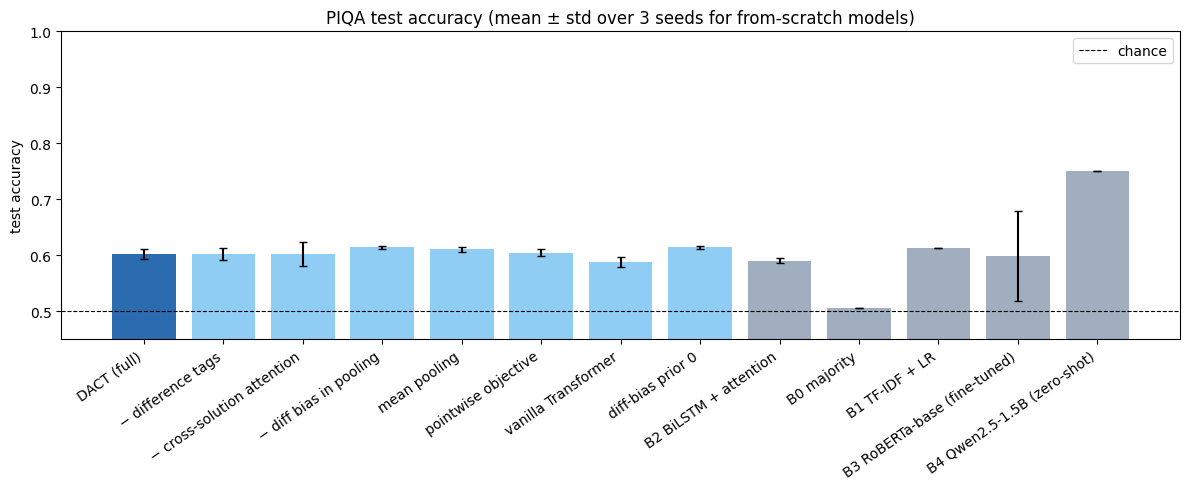

In [ ]:
order = ["DACT (full)"] + list(ABLATIONS) + ["B2 BiLSTM + attention"] + list(BASE)
R = RESULTS.set_index("model").loc[order]
fig, ax = plt.subplots(figsize=(12, 5))
colors = ["#2b6cb0"] + ["#90cdf4"] * len(ABLATIONS) + ["#a0aec0"] * (1 + len(BASE))
ax.bar(range(len(R)), R["test acc"], yerr=R["test std"].fillna(0), color=colors, capsize=3)
ax.axhline(0.5, ls="--", c="k", lw=0.8, label="chance")
ax.set_xticks(range(len(R))); ax.set_xticklabels(R.index, rotation=35, ha="right")
ax.set_ylabel("test accuracy"); ax.set_ylim(0.45, 1.0); ax.legend()
ax.set_title("PIQA test accuracy (mean ± std over 3 seeds for from-scratch models)")
plt.tight_layout(); plt.savefig(os.path.join(CFG.out_dir, "results", "test_accuracy.png"), dpi=120); plt.show()

### Where do DACT and the baselines disagree? (error overlap)
Accuracy alone cannot tell whether DACT and TF-IDF + LR get the *same* items right. For each pair we count the test items both / only one / neither model answer correctly (representative runs, chosen on validation). A high *oracle* accuracy (right if either model is right) compared with both models means they rely on different cues; an oracle close to the better model means one model's knowledge is essentially a subset of the other's.

In [ ]:
PAIRS = {"B1 TF-IDF + LR": BASE["B1 TF-IDF + LR"]["test_pred"],
         "B2 BiLSTM + attention": EXP["B2 BiLSTM + attention"]["test_preds"]["pred"],
         "vanilla Transformer": EXP["vanilla Transformer"]["test_preds"]["pred"],
         "B3 RoBERTa-base (fine-tuned)": BASE["B3 RoBERTa-base (fine-tuned)"]["test_pred"]}
OVERLAP = pd.DataFrame({name: error_overlap(ref, pred, yte) for name, pred in PAIRS.items()}).T
OVERLAP.columns = ["both correct", "only DACT", "only other", "both wrong", "agreement", "oracle"]
OVERLAP.to_csv(os.path.join(CFG.out_dir, "results", "error_overlap.csv"))
display(OVERLAP.round(3))

,both correct,only DACT,only other,both wrong,agreement,oracle
B1 TF-IDF + LR,0.479,0.132,0.133,0.256,0.735,0.744
B2 BiLSTM + attention,0.450,0.162,0.146,0.243,0.693,0.757
vanilla Transformer,0.489,0.122,0.101,0.288,0.777,0.712
B3 RoBERTa-base (fine-tuned),0.442,0.169,0.201,0.187,0.629,0.813


In [ ]:
# Items DACT gets right and TF-IDF + LR gets wrong: what does the neural model add beyond word statistics?
only_dact = np.where((ref == yte) & (BASE["B1 TF-IDF + LR"]["test_pred"] != yte))[0]
print(f"{len(only_dact)} test items are solved by DACT but not by TF-IDF + LR; three of them:")
for j in only_dact[:3]:
    r = DATA["test"][j]
    print(f"--- test item {j} | gold = option {r['label'] + 1}\n  goal: {r['goal']}\n  sol1: {r['sol1']}\n  sol2: {r['sol2']}")

243 test items are solved by DACT but not by TF-IDF + LR; three of them:
--- test item 4 | gold = option 1
  goal: ice box
  sol1: will turn into a cooler if you add water to it
  sol2: will turn into a cooler if you add soda to it
--- test item 6 | gold = option 2
  goal: Recycle a spray bottle for a new cleaner.
  sol1: Open the top of the empty spray bottle and check for damage. Rinse the bottle then fill halfway with warm water. Replace the spray nozzle and pump a few times to clear the hose. Empty sparrow bottle and allow to dry before using with a new cleaner.
  sol2: Open the top of the empty spray bottle and check for damage. Rinse the bottle then fill halfway with warm water. Replace the spray nozzle and pump a few times to clear the hose. Empty spray bottle and allow to dry before using with a new cleaner.
--- test item 20 | gold = option 1
  goal: What alcohol do you pour for a mojito?
  sol1: Fill the glass with ice cubes so it’s half full. Pour in 2 shots of white rum & 1-

In [ ]:
# Every number quoted in the discussion below, in percent, straight from RESULTS (copy from here, never retype).
R = RESULTS.set_index("model")
KEY = (R[["n seeds", "val acc", "val std", "test acc", "test std"]] * [1, 100, 100, 100, 100]).round(1)
KEY["val Δ vs DACT"] = (KEY["val acc"] - KEY.loc["DACT (full)", "val acc"]).round(1)
KEY["test Δ vs DACT"] = (KEY["test acc"] - KEY.loc["DACT (full)", "test acc"]).round(1)
display(KEY)

,n seeds,val acc,val std,test acc,test std,val Δ vs DACT,test Δ vs DACT
model,,,,,,,
DACT (full),3,59.4,0.9,60.2,0.8,0.0,0.0
− difference tags,3,59.5,0.4,60.2,1.1,0.1,0.0
− cross-solution attention,3,59.9,0.9,60.2,2.1,0.5,0.0
− diff bias in pooling,3,59.0,0.4,61.4,0.3,-0.4,1.2
mean pooling,3,59.6,0.7,61.1,0.4,0.2,0.9
pointwise objective,3,59.4,0.4,60.5,0.7,0.0,0.3
vanilla Transformer,3,58.9,0.2,58.7,0.9,-0.5,-1.5
diff-bias prior 0,3,59.0,0.4,61.4,0.3,-0.4,1.2
B2 BiLSTM + attention,3,59.6,0.8,59.0,0.5,0.2,-1.2


### Quantitative discussion

All numbers below are printed by the key-numbers cell above (percent; mean ± std over 3 seeds where *n seeds* = 3).

**Main comparison.**

| Model | Val | Test |
|---|---|---|
| **DACT (ours)** | **59.4 ± 0.9** | **60.2 ± 0.8** |
| Vanilla Transformer (same budget, no DACT components) | 58.9 ± 0.2 | 58.7 ± 0.9 |
| B2 BiLSTM + attention | 59.6 ± 0.8 | 59.0 ± 0.5 |
| B1 TF-IDF + logistic regression | 59.2 | 61.2 |
| B3 RoBERTa-base, fine-tuned (3 seeds) | 61.5 ± 6.8 | 59.9 ± 8.0 |
| B4 Qwen2.5-1.5B, zero-shot | 78.2 | 75.1 |

0. **Selected configuration.** In Step 1 the *small* model (d = 128, 2 layers, 1.67 M parameters) and *base + MLM warm-up* tied at 60.3 % validation accuracy; the first maximum, the smaller and cheaper model without warm-up, was selected. Grid differences of about 1 point are within seed noise (the seed std of the main model is 0.9), so the grid mainly shows that size, dropout and the warm-up matter little here. Because the selected model has no warm-up, the *− MLM warm-up* ablation does not apply in this run.
1. **DACT is at the level of the other from-scratch models, not clearly above them.** It beats the vanilla Transformer by +0.5 (val) and +1.5 (test) points, and the BiLSTM by +1.2 on test but −0.2 on validation. With 1,838 test items the 95 % CI of a single model spans about ±2.2 points; McNemar tests of DACT's representative run against the vanilla Transformer, the BiLSTM and TF-IDF + LR give p = 0.054, 0.24 and 1.0.
2. **A bag-of-words model is as good as every from-scratch neural model.** TF-IDF + LR on the *difference* of the two solutions reaches 59.2 % (val) and 61.2 % (test), 1 point above DACT on test. With 14.5 k training items and no external text, most of the learnable signal is which words tend to appear in plausible solutions.
3. **Fine-tuning a pretrained encoder is unstable.** RoBERTa's three seeds reached 64.4, 53.7 and 66.3 % validation accuracy: seed 43 never left chance level (training loss stayed at ≈ 0.694 for all 4 epochs), a known failure mode of fine-tuning on small datasets (Dodge et al., 2020). The mean (59.9 % test) is therefore no better than DACT, while the representative run (best validation seed, 44) reaches about 64 % on test (95 % CI 62.3-66.5). An earlier single A100 run of the same code reached 68.5 %, which shows how much one RoBERTa number depends on the seed and hardware.
4. **Pretrained knowledge is the main bottleneck.** The zero-shot 1.5 B-parameter LLM is about 15 points above every from-scratch model without any training on PIQA, which agrees with PIQA testing physical commonsense rather than reading skill.

**Ablations** (Δ vs full DACT; validation is the split used for decisions):

| Ablation | Val Δ | Test Δ |
|---|---|---|
| − difference tags | +0.1 | 0.0 |
| − cross-solution attention | +0.5 | 0.0 |
| − diff bias in pooling | −0.4 | +1.2 |
| diff-bias prior 0 | −0.4 | +1.2 |
| mean pooling | +0.2 | +0.9 |
| pointwise objective | 0.0 | +0.3 |
| **all DACT components removed (vanilla)** | **−0.5** | **−1.5** |

* No single-component ablation changes validation accuracy by more than 0.5 points, i.e. less than one seed std. On test, removing the pooling bias or using mean pooling is 0.9-1.2 points *better*, in the opposite direction to validation. We report this as noise and did not change the model afterwards, because the test split must not drive design decisions.
* *diff-bias prior 0* gives the same result as removing the tag bias altogether: the initial value of the bias has no effect on accuracy.
* Only removing *all* components is worse on both splits (−0.5 / −1.5; McNemar p = 0.054 on test). The components are **redundant**: the difference tags, the diff-biased pooling and the cross-solution attention all tell the model where the options differ, so any one of them recovers most of the benefit. The honest conclusion is that making the difference between the options explicit helps a little, and none of the individual mechanisms is indispensable.

**Where DACT and TF-IDF + LR disagree.** They agree on 73.5 % of test items, and each solves about 13 % that the other gets wrong (DACT alone: 243 items). The oracle accuracy (74.4 %) shows the two models use partly different cues: the items only DACT solves have a one-word difference inside long shared text (*water* vs *soda*, *half full* vs *all full*, the typo *sparrow bottle* vs *spray bottle*), where a bag-of-words difference vector has almost nothing to work with. Against RoBERTa the oracle rises to 81.3 %.

## 3.3 Qualitative analysis of attention
We analyse the best-validation-seed checkpoint of the full DACT. For each selected test item the figure shows:
1. **top row**: the difference-guided pooling weights over each option's tokens (the vector the scorer sees);
2. **bottom-left**: contrastive cross-solution attention from option-1 tokens (rows) to option-2 tokens (columns), averaged over heads;
3. **bottom-right**: last-encoder-layer attention from each option's tokens to the goal tokens.

Tokens that differ between the two options are shown in **bold red**. Cases: the two most confident correct predictions, the two most confident errors, and the most uncertain item.

In [ ]:
best_run = max(EXP["DACT (full)"]["runs"], key=lambda r: r["val_acc"])
DACT_BEST = DACT(BEST_CFG, DATA["vocab_size"]).to(DEVICE)
DACT_BEST.load_state_dict(torch.load(best_run["ckpt"], map_location=DEVICE))
DACT_BEST.eval()
tp = EXP["DACT (full)"]["test_preds"]
CASES = select_cases(tp["pred"], tp["prob"], tp["label"], k=2)
print(CASES)
os.makedirs(os.path.join(CFG.out_dir, "figures"), exist_ok=True)

{'confident_correct': [804, 280], 'confident_wrong': [154, 551], 'uncertain': [1458, 607]}


--- confident_correct | test item 804 | gold = option 1
  goal: Remove dust residue from chalk boards.
  sol1: Wipe down with baby wipes.
  sol2: Wipe down with index cards.


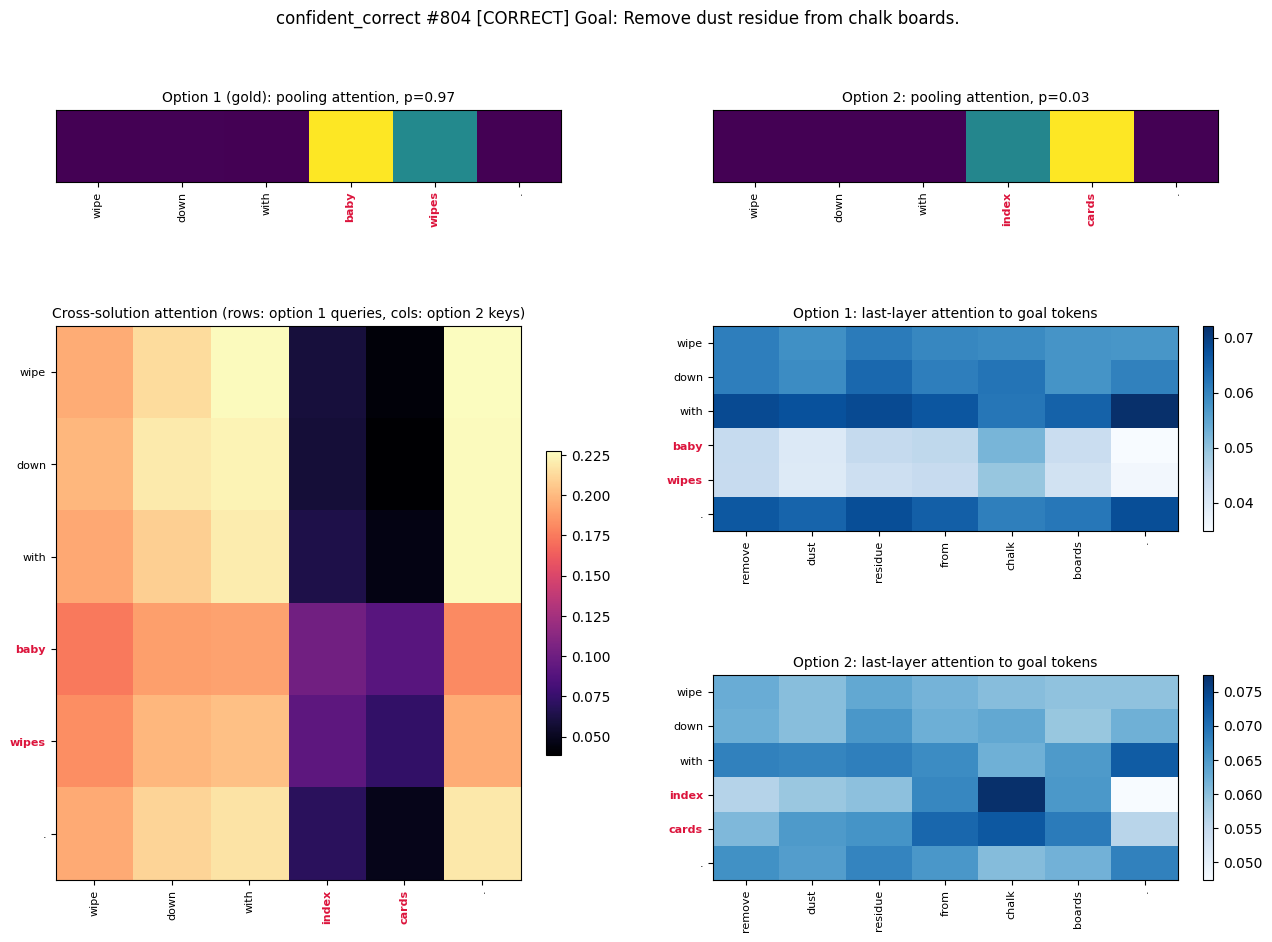

--- confident_correct | test item 280 | gold = option 1
  goal: Clean dirty cup coaster.
  sol1: Wipe with baby wipes.
  sol2: Wipe with tissue paper.


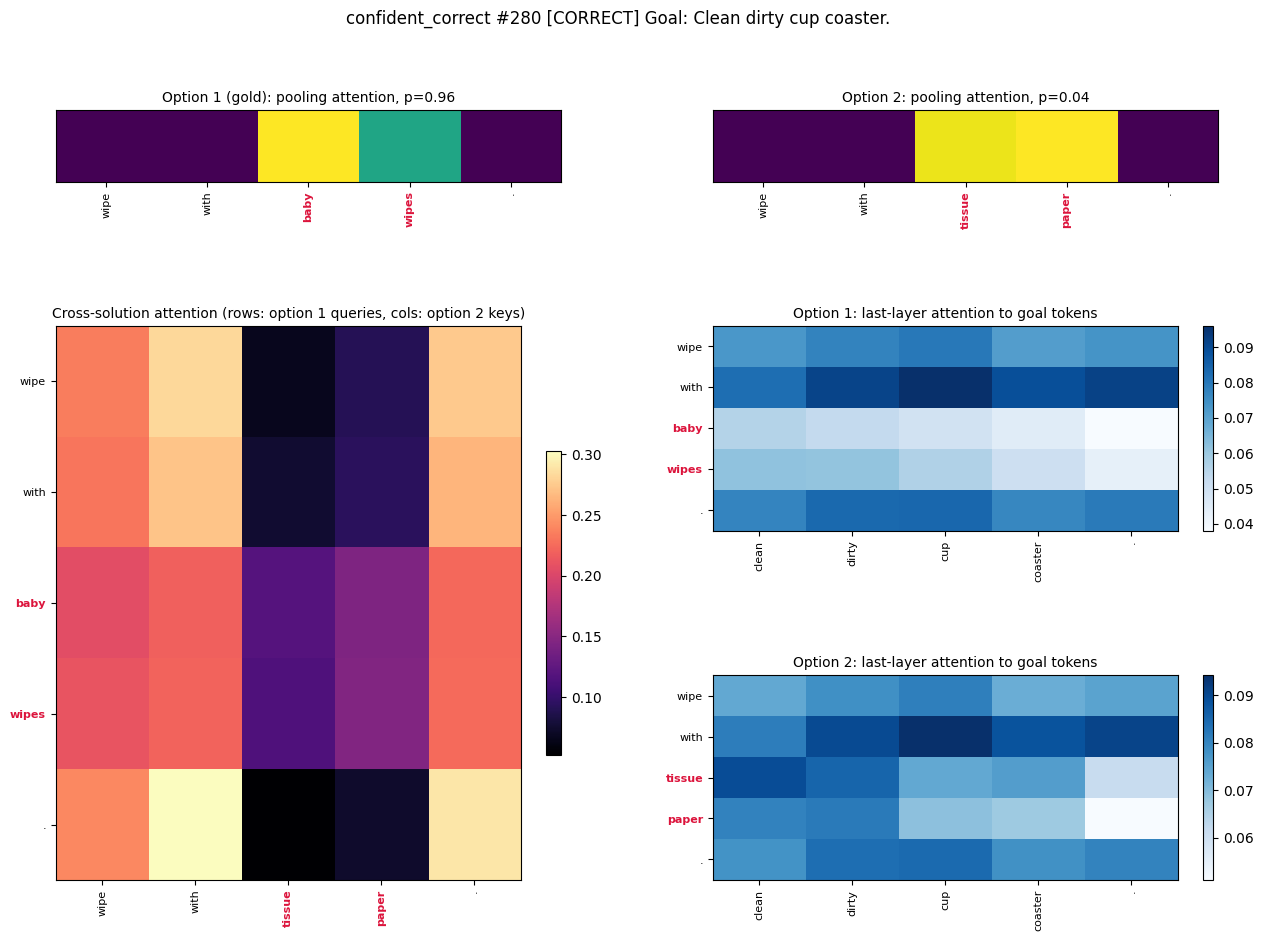

--- confident_wrong | test item 154 | gold = option 2
  goal: How to keep cool outside.
  sol1: Add some peppermint oil to a spray bottle of water, spray self often avoiding eyes.
  sol2: Sit under a shade tree.


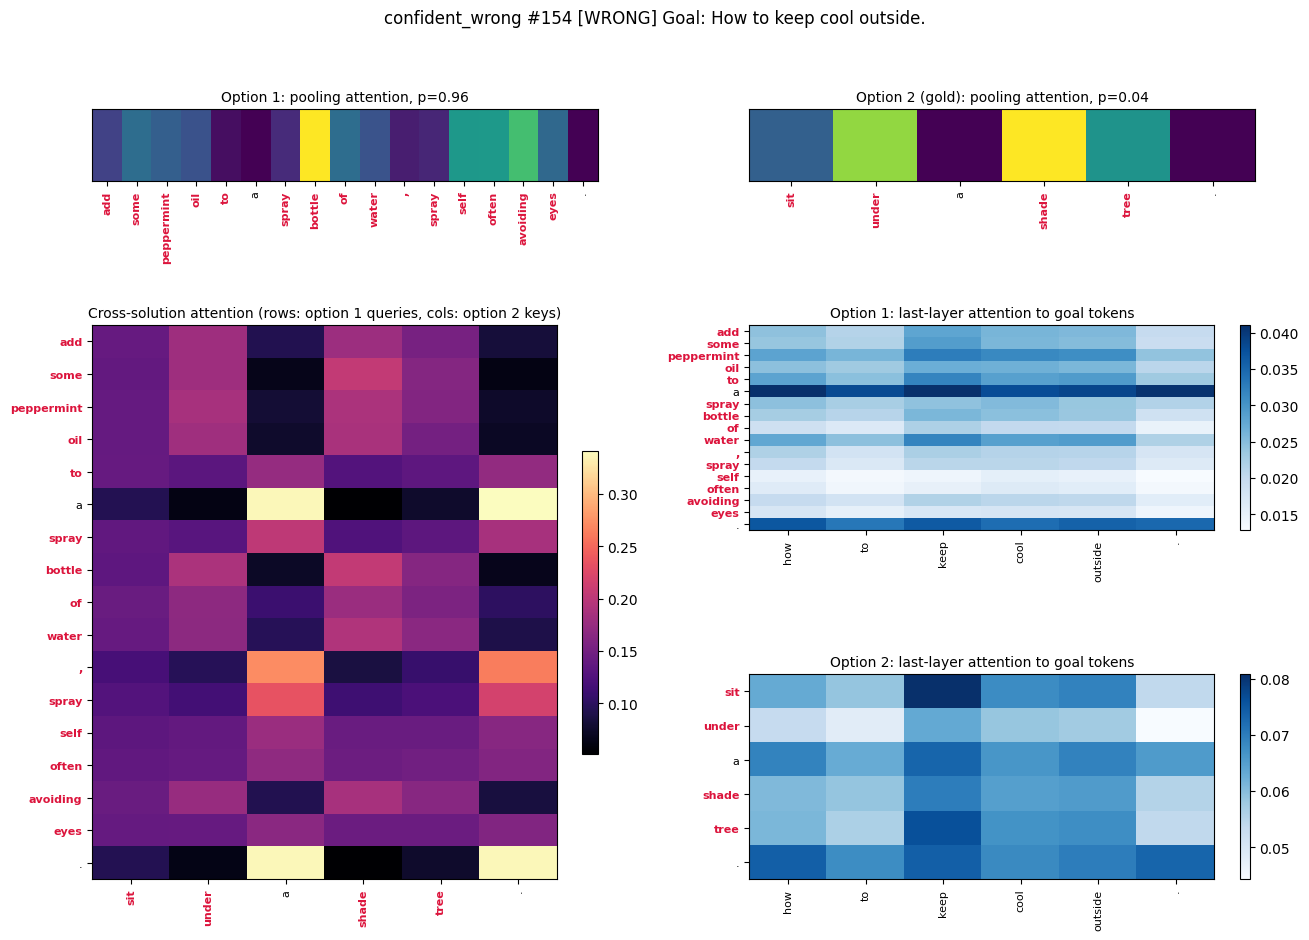

--- confident_wrong | test item 551 | gold = option 2
  goal: How to remove a stuck light bulb.
  sol1: Press the center of a foot-long strip of duct tape onto the middle of the bulb. Fold each loose end in half so it sticks onto itself. Gripping each end between your thumb and index finger, give a clockwise twist to loosen the bulb.
  sol2: Press the center of a foot-long strip of duct tape onto the middle of the bulb. Fold each loose end in half so it sticks onto itself. Gripping each end between your thumb and index finger, give a counterclockwise twist to loosen the bulb.


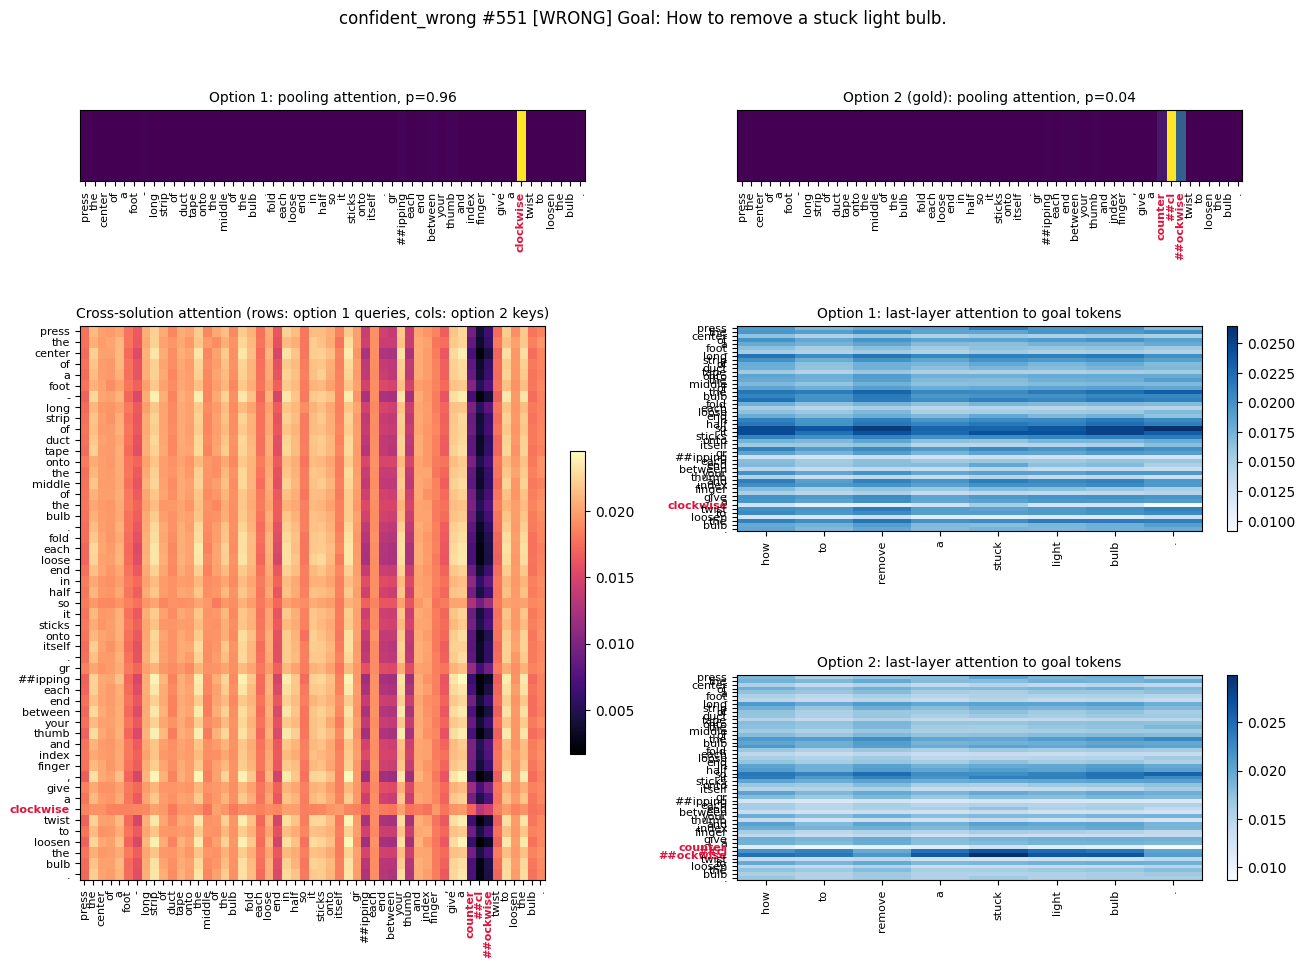

In [ ]:
for kind in ("confident_correct", "confident_wrong"):
    for i in CASES[kind]:
        r = DATA["test"][i]
        print(f"--- {kind} | test item {i} | gold = option {r['label'] + 1}\n  goal: {r['goal']}\n  sol1: {r['sol1']}\n  sol2: {r['sol2']}")
        plot_attention_case(DACT_BEST, r, DATA["tok"], BEST_CFG, DEVICE, title=f"{kind} #{i}",
                            save_path=os.path.join(CFG.out_dir, "figures", f"{kind}_{i}.png"))

--- uncertain | test item 1458 | gold = option 1
  goal: How can I clean the outside glass of a fish tank?
  sol1: Use a cloth and a spray bottle of vinegar and water on the outside glass.
  sol2: Use a cloth and a spray bottle of vinegar and water on the inside of the glass.


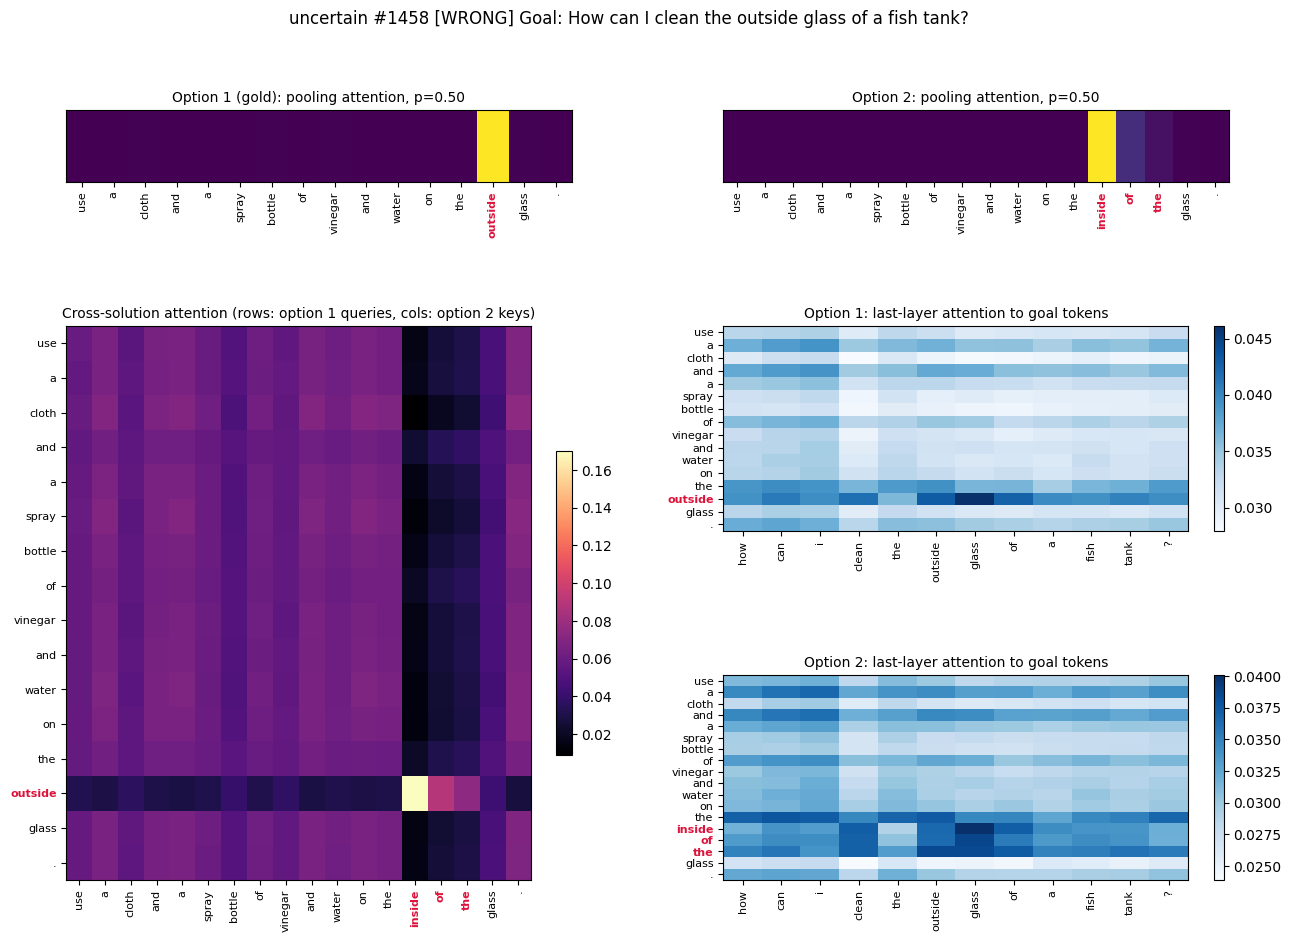

In [ ]:
i = CASES["uncertain"][0]
r = DATA["test"][i]
print(f"--- uncertain | test item {i} | gold = option {r['label'] + 1}\n  goal: {r['goal']}\n  sol1: {r['sol1']}\n  sol2: {r['sol2']}")
_ = plot_attention_case(DACT_BEST, r, DATA["tok"], BEST_CFG, DEVICE, title=f"uncertain #{i}",
                        save_path=os.path.join(CFG.out_dir, "figures", f"uncertain_{i}.png"))

### Does attention focus on the differing tokens, and does that relate to correctness?
For every test item we measure the share of pooling attention that falls on difference-tagged tokens and compare it with the share those tokens would get under uniform attention, separately for correct and wrong predictions.

**Control (revision 2).** The pooling bias for differing tokens is *initialised* at 1.0, so part of this focus is built in before any training. We therefore also measure the mass (a) of the same trained model with the tag bias set to 0, i.e. the focus coming only from the learned token representations, and (b) of an untrained model, i.e. the focus produced by the initial bias alone. The *diff-bias prior 0* ablation (Step 3) is the matching training-time control.

learned pooling tag bias [other, shared, diff]: [ 0.    -0.025  1.025]
mean attention mass on differing tokens: 0.809 (uniform-attention reference 0.248)
  correct predictions: 0.802 | wrong predictions: 0.819
  Mann-Whitney U (correct vs wrong): p = 0.007145


,mean pooling mass on differing tokens
trained,0.809
"trained, tag bias = 0",0.672
untrained (initialisation),0.389
uniform attention (reference),0.248


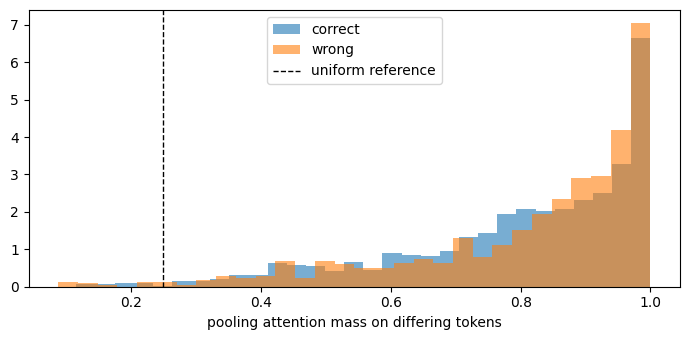

In [ ]:
from scipy.stats import mannwhitneyu
test_loader = make_loader(DATA["test_ds"], BEST_CFG, False, DEVICE)
mass, correct = diff_attention_mass(DACT_BEST, test_loader, DEVICE)
uniform = diff_token_share(test_loader)
print(f"learned pooling tag bias [other, shared, diff]: {DACT_BEST.pool.tag_bias.detach().cpu().numpy().round(3)}")
print(f"mean attention mass on differing tokens: {mass.mean():.3f} (uniform-attention reference {uniform.mean():.3f})")
print(f"  correct predictions: {mass[correct].mean():.3f} | wrong predictions: {mass[~correct].mean():.3f}")
print("  Mann-Whitney U (correct vs wrong): p = %.4g" % mannwhitneyu(mass[correct], mass[~correct]).pvalue)
CONTROLS = diff_attention_controls(DACT_BEST, BEST_CFG, DATA["vocab_size"], test_loader, DEVICE)
CONTROLS["uniform attention (reference)"] = float(uniform.mean())
display(pd.Series(CONTROLS, name="mean pooling mass on differing tokens").round(3).to_frame())
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.hist(mass[correct], bins=30, alpha=0.6, density=True, label="correct")
ax.hist(mass[~correct], bins=30, alpha=0.6, density=True, label="wrong")
ax.axvline(uniform.mean(), c="k", ls="--", lw=1, label="uniform reference")
ax.set_xlabel("pooling attention mass on differing tokens"); ax.legend()
plt.tight_layout(); plt.savefig(os.path.join(CFG.out_dir, "figures", "diff_attention_mass.png"), dpi=120); plt.show()

### Why does DACT not beat a bag-of-words baseline? Two testable explanations
TF-IDF + LR scores at least as well as DACT on test, on a task built around lexical differences. We test two explanations on the **validation** split (no test data is used for this diagnosis):

* **H1: the pooling does not select.** If the pooling weights are close to uniform (normalised entropy near 1), the scorer sees an average over the solution, not the decisive words.
* **H2: the difference signal does not survive the encoder.** A linear probe tries to tell differing from shared solution tokens at every layer. For DACT the tag is injected at the input, so a probe score that falls with depth means the signal fades. For the vanilla Transformer (no tags), compare each layer with its *embedding* row: word identity alone already predicts some differing tokens (some words appear mostly in substituted spans), so only a rise above the embedding score shows that the encoder works out the difference from context, which is what the tags were meant to supply.

In [ ]:
val_loader = make_loader(DATA["val_ds"], BEST_CFG, False, DEVICE)
ent, ent_correct = pooling_entropy(DACT_BEST, val_loader, DEVICE)
print(f"H1  normalised pooling entropy (1 = uniform): mean {ent.mean():.3f} | correct {ent[ent_correct].mean():.3f} "
      f"| wrong {ent[~ent_correct].mean():.3f} | Mann-Whitney p = {mannwhitneyu(ent[ent_correct], ent[~ent_correct]).pvalue:.3g}")

van_res = EXP["vanilla Transformer"]
van_cfg = Config(**van_res["config"])
VANILLA = DACT(van_cfg, DATA["vocab_size"]).to(DEVICE)
VANILLA.load_state_dict(torch.load(max(van_res["runs"], key=lambda r: r["val_acc"])["ckpt"], map_location=DEVICE))
probe_train = make_loader(DATA["train_ds"], BEST_CFG, True, DEVICE)
PROBE = pd.DataFrame({
    "DACT (tags injected)": pd.DataFrame(diff_probe_by_layer(DACT_BEST, probe_train, val_loader, DEVICE)).set_index("layer")["balanced acc"],
    "vanilla (no tags)": pd.DataFrame(diff_probe_by_layer(VANILLA, probe_train, val_loader, DEVICE)).set_index("layer")["balanced acc"],
})
PROBE.to_csv(os.path.join(CFG.out_dir, "results", "diff_probe_by_layer.csv"))
print("H2  linear-probe balanced accuracy for 'differing vs shared' solution tokens (0.5 = chance):")
display(PROBE.round(3))
del VANILLA

H1  normalised pooling entropy (1 = uniform): mean 0.553 | correct 0.559 | wrong 0.543 | Mann-Whitney p = 0.0716


H2  linear-probe balanced accuracy for 'differing vs shared' solution tokens (0.5 = chance):


,DACT (tags injected),vanilla (no tags)
layer,,
embedding,1.0,0.584
encoder 1,1.0,0.611
encoder 2,1.0,0.600


### Qualitative discussion

**Is the focus on differing tokens learned or built in?** The trained model puts **80.9 %** of its pooling attention on the differing tokens, which make up only 24.8 % of solution tokens. The controls separate the sources of this focus:
* an **untrained** model with the same initial bias puts 38.9 % there: the built-in prior alone gives only a modest focus;
* the **trained model with the tag bias set to 0** still puts **67.2 %** there: most of the focus comes from what the pooling scorer learned about the token representations, not from the bias;
* the bias itself hardly moved in training (differing tokens 1.0 → 1.025, shared tokens 0 → −0.025) and adds the remaining ≈ 14 points.

So in this run the focus is genuinely learned, which also explains why the *diff-bias prior 0* ablation changes nothing. Wrong predictions put slightly *more* attention on the differing tokens than correct ones (81.9 % vs 80.2 %, Mann-Whitney p = 0.007): **looking at the right tokens is not the bottleneck; judging them is.**

**Why DACT does not beat bag-of-words (validation split).**
* *H1 (the pooling does not select)* is rejected: the normalised pooling entropy is 0.55 (1 = uniform), for correct and wrong predictions alike (0.56 vs 0.54, p = 0.07).
* *H2 (the difference signal is missing)*: in the vanilla Transformer a linear probe separates differing from shared tokens with 58.4 % balanced accuracy at the embedding layer and at most 61.1 % after the encoder layers, i.e. the encoder adds under 3 points: without tags the model barely works out *where* the options differ. In DACT the injected tag stays perfectly decodable in every layer (100 %). The tags therefore supply information the encoder does not learn by itself, yet removing them does not lower accuracy (ablations). Knowing where the options differ is not what limits the model; deciding which differing word is physically right needs knowledge that 14.5 k items do not contain.

**Success: "Remove dust residue from chalk boards", *baby wipes* ✓ vs *index cards* (p = 0.97)**, and the similar "Clean dirty cup coaster", *baby wipes* ✓ vs *tissue paper*. Pooling sits almost entirely on the substituted nouns. Each option's tokens attend in the cross-solution block mainly to the rival's *shared* words (*wipe down with*) and least to the rival's differing words, so the comparison contrasts each option's substitute against the common context. In the last encoder layer *index* attends strongly to the goal word *chalk*. Both successes reuse a **lexical prior from the training split**: *baby wipe(s)* appears only in the correct option of 26 training items and only in the wrong option of 5, while *tissue paper* appears only in the correct option 3 times and only in the wrong option 24 times. The model is confident because it has seen these phrases, not because it reasons about absorbency.

**Failure 1: "How to remove a stuck light bulb", *clockwise* vs *counterclockwise* (gold) (p = 0.96 for the wrong option).** The two long instructions differ in a single word. Pooling finds it exactly: *clockwise* in option 1 and the sub-word *##cl* of *counter ##cl ##ockwise* in option 2. The model cannot know the "lefty-loosey" convention from the training data, and BPE splits the decisive word into three pieces, so the pooled vector of option 2 is built from a meaningless fragment. This is a focus success and a knowledge failure.

**Failure 2: "How to keep cool outside", *peppermint-oil water spray* vs *sit under a shade tree* (gold) (p = 0.96 for the wrong option).** The options share no words, so every token is tagged *different* and the tags carry no information; the pooling spreads over *bottle*, *self*, *avoiding* and *under*, *shade*. This case is outside DACT's inductive bias, which assumes near-duplicate options, and the model falls back on preferring the longer, more specific instruction.

**Uncertain case: "Clean the outside glass of a fish tank", *on the outside glass* (gold) vs *on the inside of the glass* (p = 0.50).** Everything works except the decision: pooling selects *outside* / *inside*, the cross-solution attention aligns *outside* with *inside* (the strongest cell of the map), and in the last layer *outside* attends to the goal's *glass*. Yet both options score the same, although the goal itself contains the word *outside*. DACT has no explicit goal-solution matching term, so a simple lexical overlap cue that a human would use is not exploited. The cobbler item that the prefix truncation made undecidable in the first run is no longer among the two most uncertain items, consistent with difference-aware truncation now keeping its differing words.

**Summary.** The attention analysis supports the design at the level of *focus*: DACT learns to concentrate on the words where the options differ and aligns substituted phrases. It also shows the model's limits: the errors come from judging those words with word statistics from the training split instead of physical knowledge (*clockwise*), from options that are not near-duplicates (*shade tree*), and from the lack of an explicit goal-solution match (*outside*). Pretraining (B3/B4) addresses the first; the last suggests an easy extension.

## Consistency check
The marking guide penalises differences between the report, the code and the logs. This cell checks that the saved result files match the tables above and that every training run left a log.

In [ ]:
import glob, subprocess
saved = pd.read_csv(os.path.join(CFG.out_dir, "results", "final_results.csv"))
assert np.allclose(saved["test acc"], RESULTS["test acc"]) and list(saved["model"]) == list(RESULTS["model"]), "final_results.csv is stale"
for name, res in EXP.items():
    with open(os.path.join(CFG.out_dir, "results", f"{res['name']}_val.json")) as f:
        assert abs(json.load(f)["val"]["mean"] - res["val"]["mean"]) < 1e-9, f"{name}: val json differs"
    for r in res["runs"]:
        assert os.path.isfile(os.path.join(CFG.out_dir, "logs", f"{res['name']}_seed{r['seed']}.jsonl")), f"missing log for {name}"
print(f"OK: {len(RESULTS)} result rows, {sum(len(r['runs']) for r in EXP.values())} training runs with logs, "
      f"{len(glob.glob(os.path.join(CFG.out_dir, 'logs', '*.jsonl')))} log files")
if os.path.isfile("tools/sync_notebook.py"):   # only when run from a checkout of the repository
    print(subprocess.run([sys.executable, "tools/sync_notebook.py", "--check"], capture_output=True, text=True).stdout)

OK: 13 result rows, 27 training runs with logs, 37 log files


In [ ]:
# Persist logs, results and figures (checkpoints excluded to save space): copy to Google Drive when it is mounted,
# and on Colab also pack them into outputs.zip and download it to the browser's computer.
import shutil
if not SMOKE and os.path.isdir("/content/drive/MyDrive"):
    dst = "/content/drive/MyDrive/Group69/outputs"
    shutil.copytree(CFG.out_dir, dst, dirs_exist_ok=True, ignore=shutil.ignore_patterns("checkpoints"))
    print("copied to", dst)
if not SMOKE and _in_colab():
    shutil.copytree(CFG.out_dir, "/tmp/outputs", dirs_exist_ok=True, ignore=shutil.ignore_patterns("checkpoints"))
    archive = shutil.make_archive("/content/outputs", "zip", "/tmp", "outputs")
    print("packed", archive, f"({os.path.getsize(archive) / 1e6:.1f} MB)")
    from google.colab import files
    files.download(archive)
print(sorted(os.listdir(os.path.join(CFG.out_dir, "logs")))[:10], "...")

packed /content/outputs.zip (0.9 MB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

['B3_roberta-base_seed42.jsonl', 'B3_roberta-base_seed43.jsonl', 'B3_roberta-base_seed44.jsonl', 'abl0_seed42.jsonl', 'abl0_seed43.jsonl', 'abl0_seed44.jsonl', 'abl1_seed42.jsonl', 'abl1_seed43.jsonl', 'abl1_seed44.jsonl', 'abl2_seed42.jsonl'] ...


# References
Full BibTeX entries are in `references.bib` (used for the report).

* Bisk, Y., Zellers, R., Le Bras, R., Gao, J., & Choi, Y. (2020). PIQA: Reasoning about Physical Commonsense in Natural Language. *AAAI*.
* Vaswani, A. et al. (2017). Attention Is All You Need. *NeurIPS*.
* Xiong, R. et al. (2020). On Layer Normalization in the Transformer Architecture. *ICML* (pre-LN encoder blocks).
* Chen, Q. et al. (2017). Enhanced LSTM for Natural Language Inference. *ACL* (ESIM `[h; c; h−c; h⊙c]` fusion used in the cross-solution block).
* Bahdanau, D., Cho, K., & Bengio, Y. (2015). Neural Machine Translation by Jointly Learning to Align and Translate. *ICLR* (additive attention pooling).
* Devlin, J. et al. (2019). BERT: Pre-training of Deep Bidirectional Transformers for Language Understanding. *NAACL* (masked-LM objective of the warm-up).
* Liu, Y. et al. (2019). RoBERTa: A Robustly Optimized BERT Pretraining Approach. *arXiv:1907.11692* (baseline B3).
* Qwen Team (2024). Qwen2.5 Technical Report. *arXiv:2412.15115* (baseline B4).
* Sennrich, R., Haddow, B., & Birch, A. (2016). Neural Machine Translation of Rare Words with Subword Units. *ACL* (BPE tokenizer).
* Gururangan, S. et al. (2018). Annotation Artifacts in Natural Language Inference Data. *NAACL* (lexical shortcuts, cf. the TF-IDF baseline).
* Jain, S., & Wallace, B. C. (2019). Attention is not Explanation. *NAACL*; Wiegreffe, S., & Pinter, Y. (2019). Attention is not not Explanation. *EMNLP* (limits of reading attention maps).
* McNemar, Q. (1947). Note on the sampling error of the difference between correlated proportions or percentages. *Psychometrika*; Efron, B., & Tibshirani, R. (1993). *An Introduction to the Bootstrap*.
* Dodge, J. et al. (2020). Fine-Tuning Pretrained Language Models: Weight Initializations, Data Orders, and Early Stopping. *arXiv:2002.06305* (seed instability of B3).
* Dror, R. et al. (2018). The Hitchhiker's Guide to Testing Statistical Significance in Natural Language Processing. *ACL*.